#### From assignment

Write your solution in here.

- Your code has to reference all data files using **relative** paths so that they can be loaded on other computers without modifications.
- All data files need to be stored in the `data/` folder.

For example:

In [1]:
import pandas as pd

# Define the path to the data directory
DATA_PATH = 'data'

# Read the CSV using a relative path
df = pd.read_csv(f'{DATA_PATH}/sce_extract_2015.csv')

# FIE463 Term Paper 2 Predicting Consumer Expectations
***

This notebook builds machine learning models to predict household expectations
about macroeconomic and financial variables using the Survey of Consumer
Expectations (SCE) and macro/finance data.

**Candidate 67 and 129**

## Import

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import validation_curve
from sklearn.model_selection import cross_validate
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.linear_model import LogisticRegressionCV

# Plot style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

In [3]:
#Ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

## Part 1 — Data Preprocessing (SCE)
***

This section loads and cleans the individual-level SCE survey data. 
The goal is to produce a clean dataset suitable for machine learning, 
by merging annual files, handling missing values, removing outliers, 
and constructing binary optimism indicators.

### 1.1 Load and merge SCE data

In [4]:
def load_sce_data(data_path):
    
    """Load and merge all SCE CSV files from the data folder."""

    files = sorted(glob.glob(os.path.join(data_path, "sce_extract_*.csv")))
    dfs = []
    for f in files:
        df = pd.read_csv(f, parse_dates=["date"])
        dfs.append(df)
    merged = pd.concat(dfs, ignore_index=True)
    return merged

In [5]:
# Load data and report initial sample
sce_raw = load_sce_data(DATA_PATH)

print("=== Initial Sample ===")
print(f"Observations : {len(sce_raw):,}")
print(f"Individuals  : {sce_raw['userid'].nunique():,}")
print(f"Survey waves : {sce_raw['wid'].nunique():,}")
print(f"First date   : {sce_raw['date'].min().date()}")
print(f"Last date    : {sce_raw['date'].max().date()}")

=== Initial Sample ===
Observations : 180,268
Individuals  : 23,886
Survey waves : 143
First date   : 2013-06-01
Last date    : 2025-05-01


The raw dataset contains 180,268 observations from 23,886 unique respondents across 143 survey waves, spanning June 2013 to May 2025.

### 1.2 Forward-fill variables asked only in the first interview

In [6]:
# Variables asked only at first interview  forward-fill within each respondent
FFILL_VARS = ["owner", "health", "age_init", "num_lit_q1", "num_lit_q1_correct",
              "num_lit_q2", "num_lit_q2_correct", "num_lit_q3", "num_lit_q3_correct",
              "num_lit_q5", "num_lit_q5_correct", "num_lit_q6", "num_lit_q6_correct",
              "num_lit_q8", "num_lit_q8_correct", "num_lit_q9", "num_lit_q9_correct"]

# Sort by user and date before forward-filling
sce = sce_raw.sort_values(["userid", "date"]).copy()
sce[FFILL_VARS] = sce.groupby("userid")[FFILL_VARS].ffill()

print(f"Forward-filled {len(FFILL_VARS)} variables within each respondent.")

Forward-filled 17 variables within each respondent.


Several variables such as age, homeownership, health, and numerical literacy are only recorded at a respondent's first interview. These are forward-filled within each respondent to make them available in subsequent waves.

### 1.3 Drop 2025 survey waves

In [7]:
# Drop 2025 observations to avoid volatility from second Trump administration
n_before = len(sce)
sce = sce[sce["date"].dt.year < 2025].copy()
n_dropped = n_before - len(sce)

print(f"Dropped {n_dropped:,} observations from 2025.")
print(f"Remaining observations: {len(sce):,}")

Dropped 4,167 observations from 2025.
Remaining observations: 176,101


The 4,167 observations from 2025 are dropped to avoid the macroeconomic volatility associated with the second Trump administration, which could distort the training and test samples.

### 1.4 Select variables and drop missing values

In [8]:
# Target variables (continuous)
TARGET_VARS = ["infl_1y", "house_price_change", "prob_unrate_up", "prob_stocks_up"]

# Individual-level predictor variables (stable demographic/literacy variables)
INDIV_VARS = ["age_init", "female", "hispanic", "black", "educ",
              "owner", "couple", "num_kids", "hh_inc_bin_rank",
              "working",
              "num_lit_q1_correct", "num_lit_q2_correct",
              "num_lit_q3_correct", "num_lit_q5_correct"]

# Keep only necessary columns
KEEP_COLS = ["userid", "wid", "date"] + TARGET_VARS + INDIV_VARS
sce = sce[KEEP_COLS].copy()

# Drop rows with missing values in any of the selected columns
n_before = len(sce)
sce = sce.dropna(subset=TARGET_VARS + INDIV_VARS)
n_dropped = n_before - len(sce)

print(f"Dropped {n_dropped:,} observations due to missing values.")
print(f"Remaining observations: {len(sce):,}")

Dropped 16,548 observations due to missing values.
Remaining observations: 159,553


Only variables available to a policymaker in real time are retained as predictors, specifically stable demographic characteristics and numerical literacy scores. Variables with high missing rates are excluded to preserve sample size.

### 1.5 Remove outliers (P1 / P99)

In [9]:
#Function to calculate P1 and P99 bounds for given variables
def get_outlier_bounds(df, variables):

    """ Calculate P1/ P99 bounds for given variables."""
    
    bounds = {}

    for var in variables:
        p1 = df[var].quantile(0.01)
        p99 = df[var].quantile(0.99)
        bounds[var] = (p1, p99)

        print(f" {var}: P1 = {p1:.2f}, P99 = {p99:.2f}")

    return bounds

In [10]:
def apply_outlier_bounds(df, bounds): 

    """Apply bounds to the dataframe removing values outside P1/P99."""

    mask = pd.Series(True, index = df.index)

    for var, (p1, p99) in bounds.items():
        mask &= (df[var] > p1) & (df[var] < p99)

    return df[mask].copy()

In [11]:
#Split into train/test for fitting outlier thresholds
sce_train_raw = sce[sce["date"] < '2024-01-01'].copy()
sce_test_raw = sce[sce["date"] >= '2024-01-01'].copy()

print("Outlier thresholds estimated on training data:")
outlier_bounds = get_outlier_bounds(sce_train_raw, TARGET_VARS)

n_train_before = len(sce_train_raw)
n_test_before = len(sce_test_raw)

sce_train = apply_outlier_bounds(sce_train_raw, outlier_bounds)
sce_test = apply_outlier_bounds(sce_test_raw, outlier_bounds)

print(f"\nDropped {n_train_before - len(sce_train):,} outliers from training set.")
print(f"Dropped {n_test_before - len(sce_test):,} outliers from test set.")

sce = pd.concat([sce_train, sce_test], ignore_index = True)
print(f"Remaining observations after outlier handling: {len(sce):,}")

Outlier thresholds estimated on training data:
 infl_1y: P1 = -30.00, P99 = 60.00
 house_price_change: P1 = -20.00, P99 = 50.00
 prob_unrate_up: P1 = 0.00, P99 = 100.00
 prob_stocks_up: P1 = 0.00, P99 = 95.00

Dropped 12,461 outliers from training set.
Dropped 1,202 outliers from test set.
Remaining observations after outlier handling: 145,890


Extreme responses are removed by keeping only observations strictly between the 1st and 99th percentiles for each target variable. This reduces the influence of implausible responses such as expected inflation of several hundred percent.

### 1.6 Create optimist indicator variables

In [12]:
# optimist_unrate: 1 if probability of unemployment increase < 50%
sce["optimist_unrate"] = (sce["prob_unrate_up"] < 50).astype(int)

# optimist_stocks: 1 if probability of stock market increase > 50%
sce["optimist_stocks"] = (sce["prob_stocks_up"] > 50).astype(int)

# optimist_house_price: 1 if expected house price change > 0
sce["optimist_house_price"] = (sce["house_price_change"] > 0).astype(int)

print("Optimist indicator variables created:")
print(f"  optimist_unrate      : {sce['optimist_unrate'].mean():.1%} optimists")
print(f"  optimist_stocks      : {sce['optimist_stocks'].mean():.1%} optimists")
print(f"  optimist_house_price : {sce['optimist_house_price'].mean():.1%} optimists")

Optimist indicator variables created:
  optimist_unrate      : 60.2% optimists
  optimist_stocks      : 30.9% optimists
  optimist_house_price : 83.1% optimists


The three binary optimist variables indicate that respondents are generally optimistic about house prices (83.1%) and unemployment (60.2%), but less so about the stock market (30.9%).

### 1.7 Final sample summary

In [13]:
print("=== Final Sample ===")
print(f"Observations : {len(sce):,}")
print(f"Individuals  : {sce['userid'].nunique():,}")
print(f"Survey waves : {sce['wid'].nunique():,}")
print(f"First date   : {sce['date'].min().date()}")
print(f"Last date    : {sce['date'].max().date()}")

=== Final Sample ===
Observations : 145,890
Individuals  : 21,847
Survey waves : 139
First date   : 2013-06-01
Last date    : 2024-12-31


The final sample contains 145,890 observations from 21,847 unique respondents across 139 survey waves, spanning June 2013 to December 2024. This is close to the target of approximately 150,000 observations.

## Part 2 - Data Preprocessing (Macro/Finance)
***

This section loads the macro/finance time series, resamples them to monthly frequency,
computes levels and changes, and merges them into the SCE dataset. Only information
available at the survey date is used to avoid look-ahead bias.

In [14]:
def load_fred(series_id, data_path):

    """Load a FRED series from CSV and return as a named Series with monthly frequency."""

    path = os.path.join(data_path, f"fred_{series_id}.csv")
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.columns = [series_id]
    
    return df[series_id].resample("ME").last()

In [15]:
def load_yahoo(filename, col, data_path):

    """Load a Yahoo Finance series from CSV and return as a named Series with monthly frequency."""

    path = os.path.join(data_path, filename)
    df = pd.read_csv(path, index_col=0, skiprows=[1])
    df.index = pd.to_datetime(df.index, format="%Y-%m-%d", errors="coerce")
    df = df[df.index.notna()]
    
    return df[col].resample("ME").last()

In [16]:
# Load all macro/finance series
cpi      = load_fred("CPIAUCSL",     DATA_PATH)
hpi      = load_fred("USSTHPI",      DATA_PATH)
fedfunds = load_fred("FEDFUNDS",     DATA_PATH)
unrate   = load_fred("UNRATE",       DATA_PATH)
gdp      = load_fred("GDPC1",        DATA_PATH)
dollar   = load_fred("DTWEXBGS",     DATA_PATH)
mortgage = load_fred("MORTGAGE30US", DATA_PATH)
oil      = load_yahoo("yahoo_WTI_oil.csv", "WTI_oil", DATA_PATH)
sp500    = load_yahoo("yahoo_SP500.csv",   "SP500",   DATA_PATH)

In [17]:
print("Macro/finance series loaded:")

for name, s in zip(
    ["CPI","HPI","FedFunds","UnRate","GDP","Dollar","Mortgage","Oil","SP500"],
    [cpi, hpi, fedfunds, unrate, gdp, dollar, mortgage, oil, sp500]
):
    
    print(f"  {name:12s}: {s.index[0].date()} to {s.index[-1].date()}, {s.notna().sum()} obs")

Macro/finance series loaded:
  CPI         : 2012-01-31 to 2024-12-31, 156 obs
  HPI         : 2012-01-31 to 2024-10-31, 52 obs
  FedFunds    : 2012-01-31 to 2024-12-31, 156 obs
  UnRate      : 2012-01-31 to 2024-12-31, 156 obs
  GDP         : 2012-01-31 to 2024-10-31, 52 obs
  Dollar      : 2012-01-31 to 2024-12-31, 156 obs
  Mortgage    : 2012-01-31 to 2024-12-31, 156 obs
  Oil         : 2012-01-31 to 2024-12-31, 156 obs
  SP500       : 2012-01-31 to 2024-12-31, 156 obs


### 2.1 Compute levels and changes

For each series, we compute:
- **Level**: the last available observation before the survey month (1-month lag)
- **12-month change**: the relative change over the past 12 months

This ensures no look-ahead bias: a respondent surveyed in May only sees data up to April.
For quarterly series (GDP and HPI), the last available quarter-end value is used and then
forward-filled to fill in the intermediate months. For example, a respondent surveyed in
May uses the Q1 GDP value (March 31), and a respondent surveyed in June uses the same
Q1 value since Q2 data is not yet available.

In [18]:
def make_macro_features(series, name):

    """
    Given a monthly series, compute level and 12-month relative change.
    Forward-fills quarterly series to fill in missing months.
    """
    
    series = series.ffill()
    df = pd.DataFrame(index=series.index)
    df[f"{name}_level"]   = series
    df[f"{name}_chg_12m"] = series.pct_change(12)
    return df

In [19]:
macro_frames = []

for series, name in [
    (cpi,      "CPI"),
    (hpi,      "HPI"),
    (fedfunds, "FEDFUNDS"),
    (unrate,   "UNRATE"),
    (gdp,      "GDP"),
    (dollar,   "DOLLAR"),
    (mortgage, "MORTGAGE"),
    (oil,      "OIL"),
    (sp500,    "SP500"),
]:
    
    macro_frames.append(make_macro_features(series, name))

macro_df = pd.concat(macro_frames, axis=1).sort_index().ffill()

print(f"Macro feature matrix: {macro_df.shape[0]} rows x {macro_df.shape[1]} columns")
print(f"Date range: {macro_df.index[0].date()} to {macro_df.index[-1].date()}")

Macro feature matrix: 156 rows x 18 columns
Date range: 2012-01-31 to 2024-12-31


### 2.2 Merge macro features into SCE dataset

Each respondent is matched to the macro data from the end of the month prior to their
survey date. This ensures that only information available at interview time is used.
For example, a respondent surveyed on May 17 is matched to April 30 macro data.

In [20]:
def merge_macro(sce, macro_df):

    """
    Merge macro features into SCE data using a 1-month lag.
    Each observation is matched to the last macro observation
    available before the survey date (end of prior month).
    """
    
    sce = sce.copy()

    # Create year-month key for previous month
    sce["merge_year"]  = (sce["date"] - pd.DateOffset(months=1)).dt.year
    sce["merge_month"] = (sce["date"] - pd.DateOffset(months=1)).dt.month

    # Create same key for macro data
    macro_reset = macro_df.reset_index()
    macro_reset.columns = [str(c) for c in macro_reset.columns]
    date_col = macro_reset.columns[0]
    macro_reset[date_col] = pd.to_datetime(macro_reset[date_col])
    macro_reset["merge_year"]  = macro_reset[date_col].dt.year
    macro_reset["merge_month"] = macro_reset[date_col].dt.month
    macro_reset = macro_reset.drop(columns=[date_col])

    # Merge on year-month keys
    sce = sce.merge(macro_reset, on=["merge_year", "merge_month"], how="left")
    sce = sce.drop(columns=["merge_year", "merge_month"])
    return sce

In [21]:
sce = merge_macro(sce, macro_df)

macro_cols = [c for c in sce.columns if any(
    c.startswith(n) for n in ["CPI","HPI","FEDFUNDS","UNRATE","GDP","DOLLAR","MORTGAGE","OIL","SP500"]
)]

n_before = len(sce)
sce = sce.dropna(subset=macro_cols)

print(f"Dropped {n_before - len(sce):,} observations with missing macro data.")
print(f"Final dataset: {len(sce):,} observations, {sce.shape[1]} columns")

Dropped 0 observations with missing macro data.
Final dataset: 145,890 observations, 42 columns


After merging, the dataset contains all 145,890 observations with 42 columns. No observations
were dropped due to missing macro data, as the forward-fill applied ensures complete coverage. The final merged dataset is ready for exploratory analysis.

### 2.3 Motivation for variable choices

The macro and finance variables are included in both levels and 12-month changes
to capture both the current state of the economy and recent momentum.

- **CPI**: captures current inflation environment, which directly anchors inflation expectations.
- **UNRATE**: reflects labor market conditions relevant for unemployment expectations.
- **SP500**: stock market performance influences optimism about future returns.
- **OIL**: oil prices are a visible signal of inflation pressure for households.
- **FEDFUNDS**: the policy rate signals the stance of monetary policy.
- **MORTGAGE**: mortgage rates affect housing affordability and house price expectations.
- **HPI**: current house prices provide a baseline for future price expectations.
- **GDP**: overall economic growth shapes general optimism about the economy.
- **DOLLAR**: the broad dollar index captures external economic conditions.

The 1-month lag ensures that no information from the survey month itself is used,
avoiding any look-ahead bias in the feature construction.

## Part 3 - Exploratory Data Analysis (SCE)
***

This section provides an overview of the four target expectations variables and the
three binary optimism indicators through histograms and time series plots.

### 3.1 Histograms of expectations variables

In [22]:
def plot_histograms(df, variables, titles, bins = 50):

    """Plot histograms for a list of variables in a 2x2 grid."""

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, var, title in zip(axes, variables, titles):
        ax.hist(df[var].dropna(), bins=bins, color="steelblue", edgecolor="white", linewidth=0.5)
        ax.set_title(title)
        ax.set_xlabel("Value")
        ax.set_ylabel("Count")
        
    fig.suptitle("Distribution of Expectations Variables", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

TITLES = [
    "1-Year Inflation Expectations (%)",
    "Expected House Price Change (%)",
    "Probability Unemployment Rate Increases (%)",
    "Probability Stock Prices Increase (%)",
]

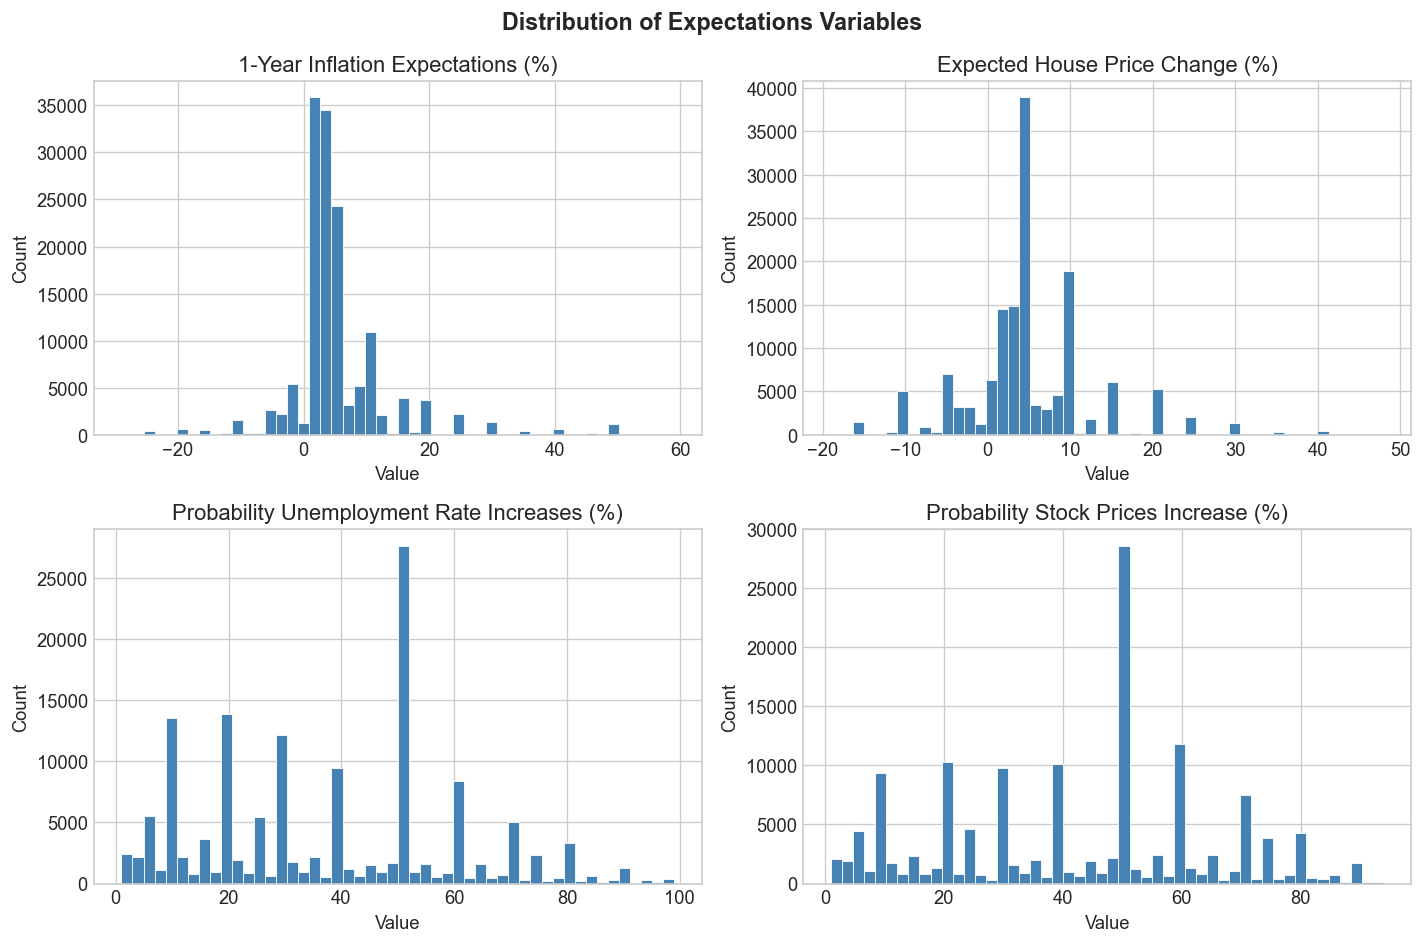

In [23]:
plot_histograms(sce, TARGET_VARS, TITLES)

Inflation expectations and house price expectations are right-skewed, with most respondents
expecting moderate positive changes. The unemployment and stock market probability variables
show a wider spread, with many respondents anchoring at round numbers such as 0, 50, and 100.

### 3.2 Time series of average expectations variables

In [24]:
def plot_expectations_timeseries(df, variables, titles):

    """Plot monthly average time series for each expectations variable."""

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()
    monthly = df.groupby(df["date"].dt.to_period("M"))[variables].mean()
    monthly.index = monthly.index.to_timestamp()

    for ax, var, title in zip(axes, variables, titles):
        ax.plot(monthly.index, monthly[var], color="steelblue", linewidth=1.5)
        ax.set_title(title)
        ax.set_xlabel("Date")
        ax.set_ylabel("Average")
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    fig.suptitle("Average Expectations Over Time", fontsize=14, fontweight="bold")
    
    plt.tight_layout()
    plt.show()

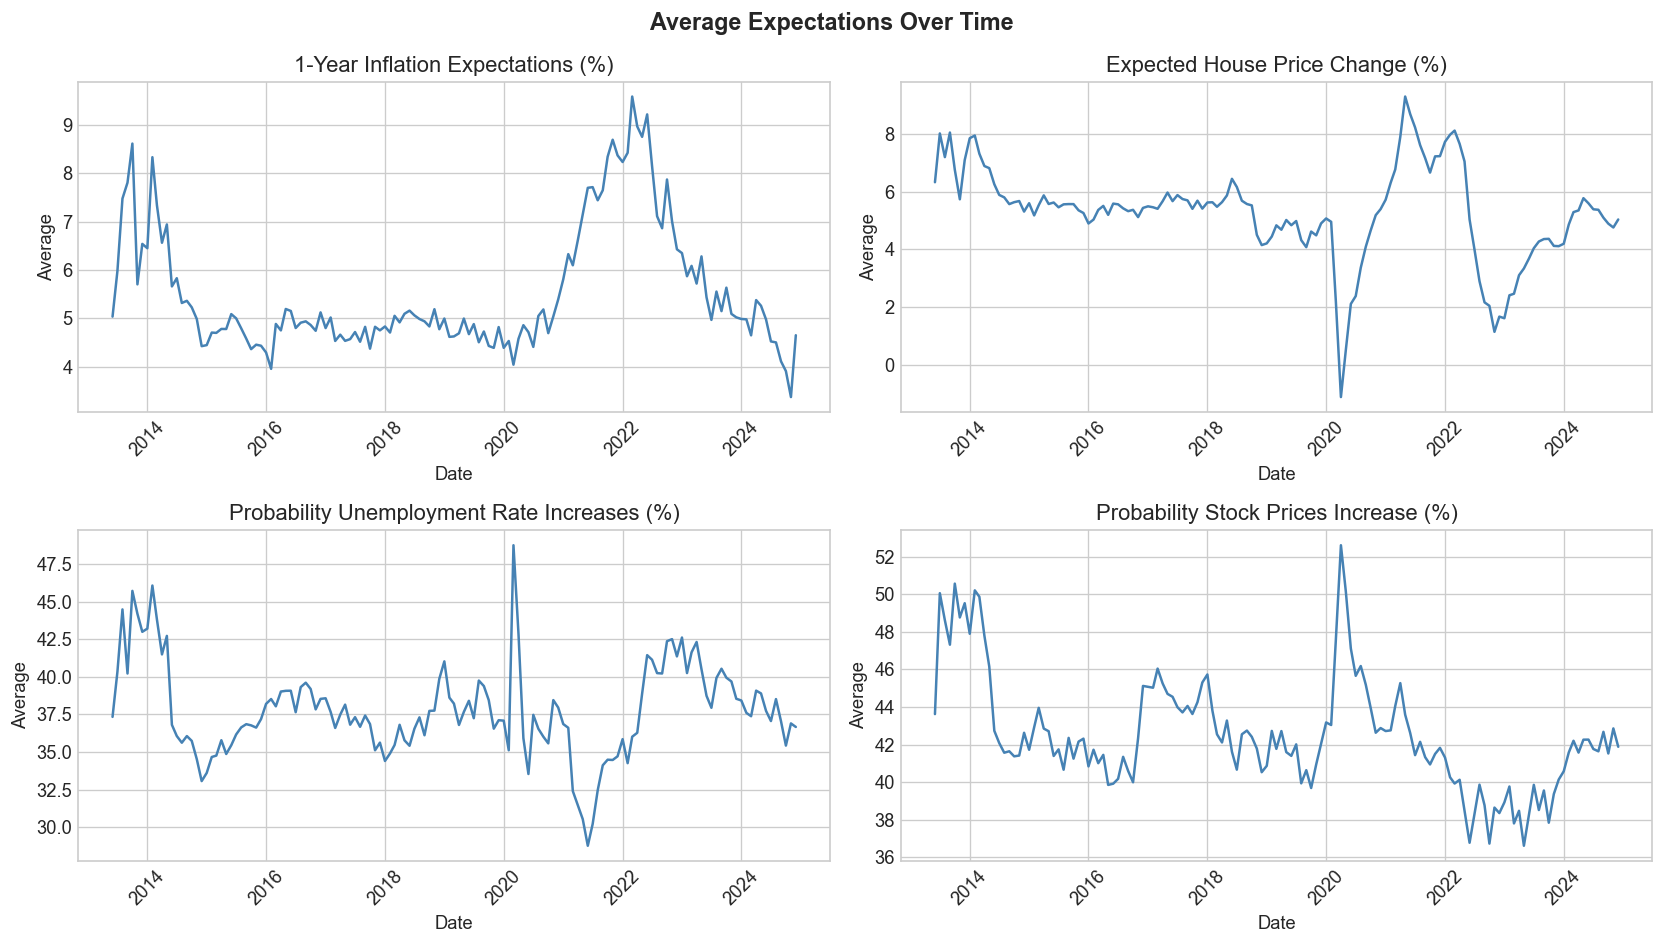

In [25]:
plot_expectations_timeseries(sce, TARGET_VARS, TITLES)

Inflation expectations rose sharply in 2021-2022 during the post-pandemic inflation surge, before declining toward more normal levels in 2023-2024. House price expectations followed a similar pattern, though they also experienced a sharp temporary drop in early 2020 during the COVID-19 shock. The probability of unemployment increasing rose during the COVID-19 recession in 2020. Stock market optimism briefly fell in early 2020 before rising sharply, likely reflecting expectations of a market recovery following the initial COVID-19 crash.

### 3.3 Time series of optimist fractions

In [26]:
def plot_optimist_timeseries(df):

    """Plot the fraction of optimists over time for each binary variable."""
    
    opt_vars = ["optimist_unrate", "optimist_stocks", "optimist_house_price"]
    opt_titles = [
        "Optimists: Unemployment (prob. increase < 50%)",
        "Optimists: Stocks (prob. increase > 50%)",
        "Optimists: House Prices (expected change > 0%)",
    ]
    monthly = df.groupby(df["date"].dt.to_period("M"))[opt_vars].mean()
    monthly.index = monthly.index.to_timestamp()
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    for ax, var, title in zip(axes, opt_vars, opt_titles):
        ax.plot(monthly.index, monthly[var] * 100, color="steelblue", linewidth=1.5)
        ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
        ax.set_title(title)
        ax.set_xlabel("Date")
        ax.set_ylabel("Fraction of optimists (%)")
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    fig.suptitle("Fraction of Optimists Over Time", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

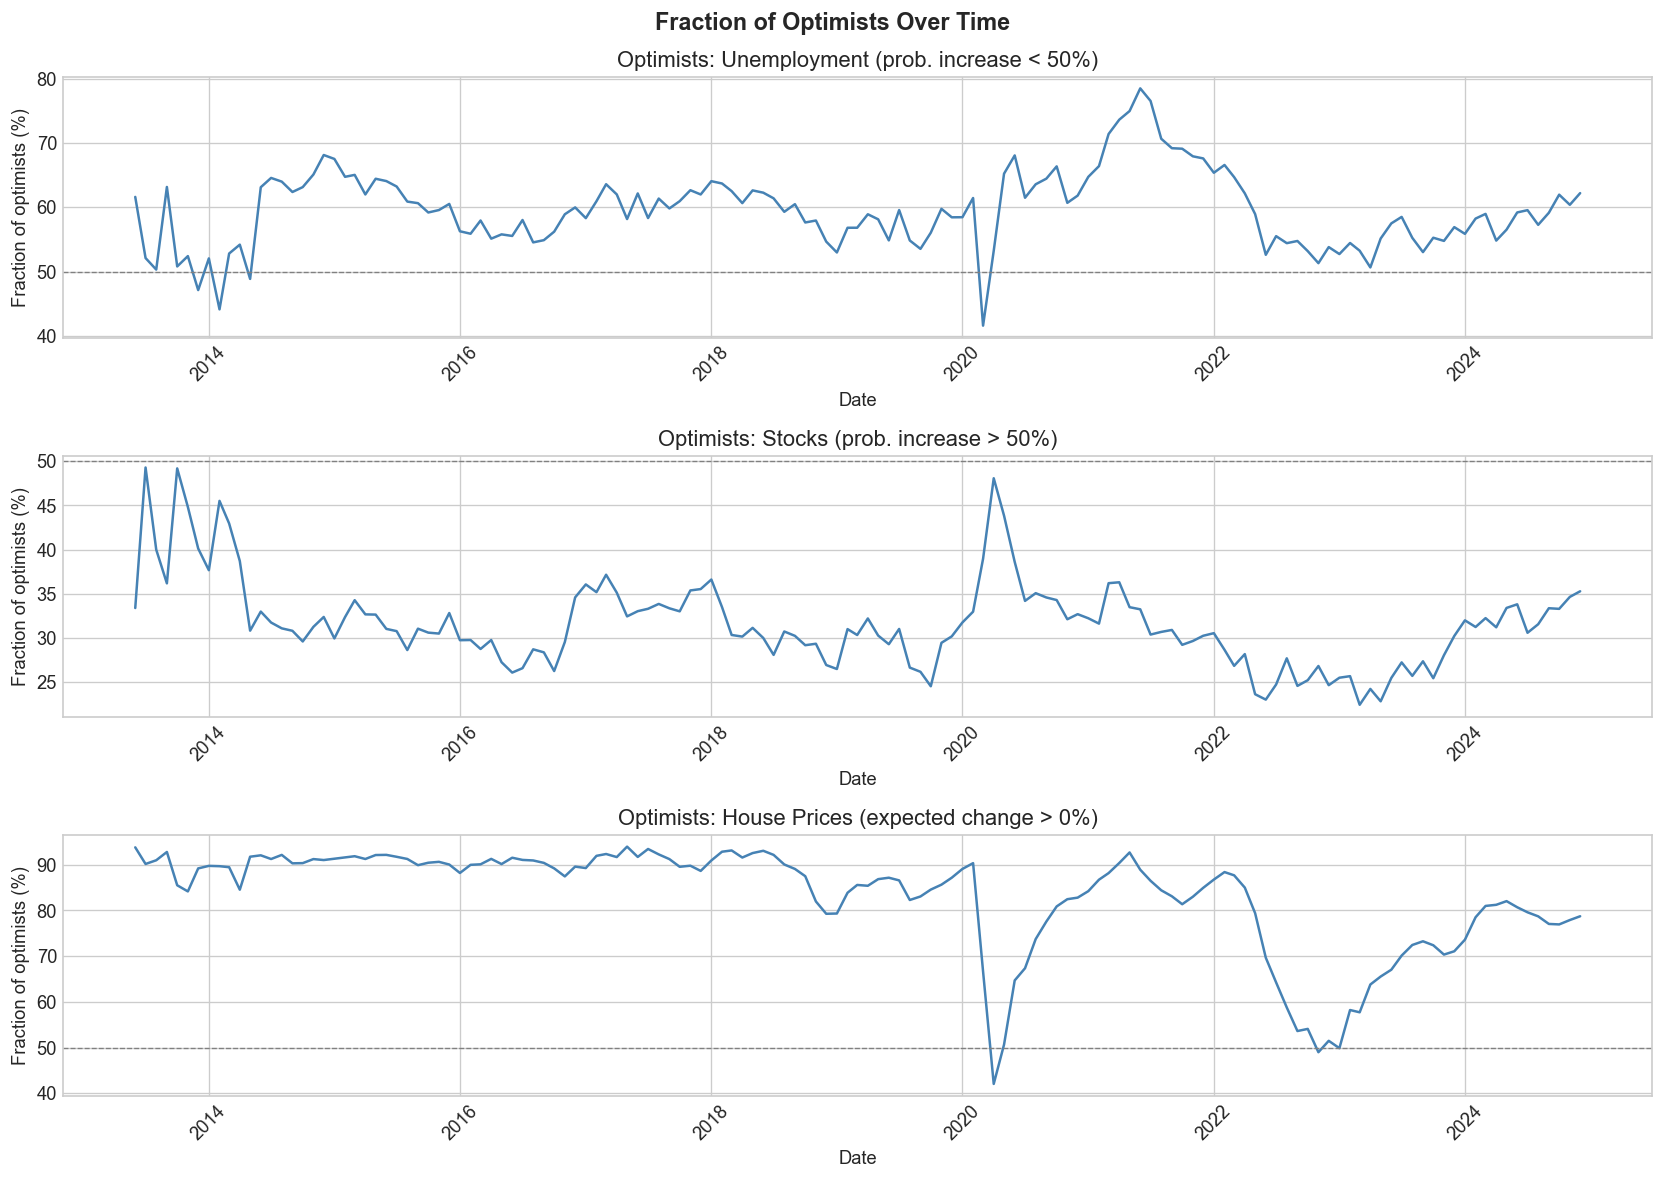

In [27]:
plot_optimist_timeseries(sce)

The fraction of respondents optimistic about house prices remained consistently high throughout the sample, though it dropped sharply to around 40% during the COVID-19 shock in early 2020 before recovering. Stock market optimism was more volatile, briefly rising in early 2020 likely reflecting recovery expectations, before falling sharply during the 2022 market downturn. Unemployment optimism declined sharply during the 2020 recession but recovered quickly and strongly as the labor market rebounded.

## Part 4 - Exploratory Data Analysis (Macro/Finance)
***

This section visualizes the macro/finance variables over the SCE sample period and
examines their correlations with the four expectations variables.

### 4.1 Time series of macro/finance variables in levels

In [28]:
def plot_macro_levels(macro_df, survey_start, survey_end):

    """Plot time series of macro/finance variables in levels over the survey period."""
    
    level_cols = [c for c in macro_df.columns if c.endswith("_level")]
    labels = {
        "CPI_level":      "CPI (Index)",
        "HPI_level":      "House Price Index",
        "FEDFUNDS_level": "Fed Funds Rate (%)",
        "UNRATE_level":   "Unemployment Rate (%)",
        "GDP_level":      "Real GDP (Bil. USD)",
        "DOLLAR_level":   "Dollar Index",
        "MORTGAGE_level": "30Y Mortgage Rate (%)",
        "OIL_level":      "WTI Oil Price (USD)",
        "SP500_level":    "S&P 500 Index",
    }
    df = macro_df.loc[survey_start:survey_end, level_cols].copy()
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    axes = axes.flatten()
    for ax, col in zip(axes, level_cols):
        ax.plot(df.index, df[col], color="steelblue", linewidth=1.5)
        ax.set_title(labels.get(col, col))
        ax.set_xlabel("Date")
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    fig.suptitle("Macro/Finance Variables in Levels", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

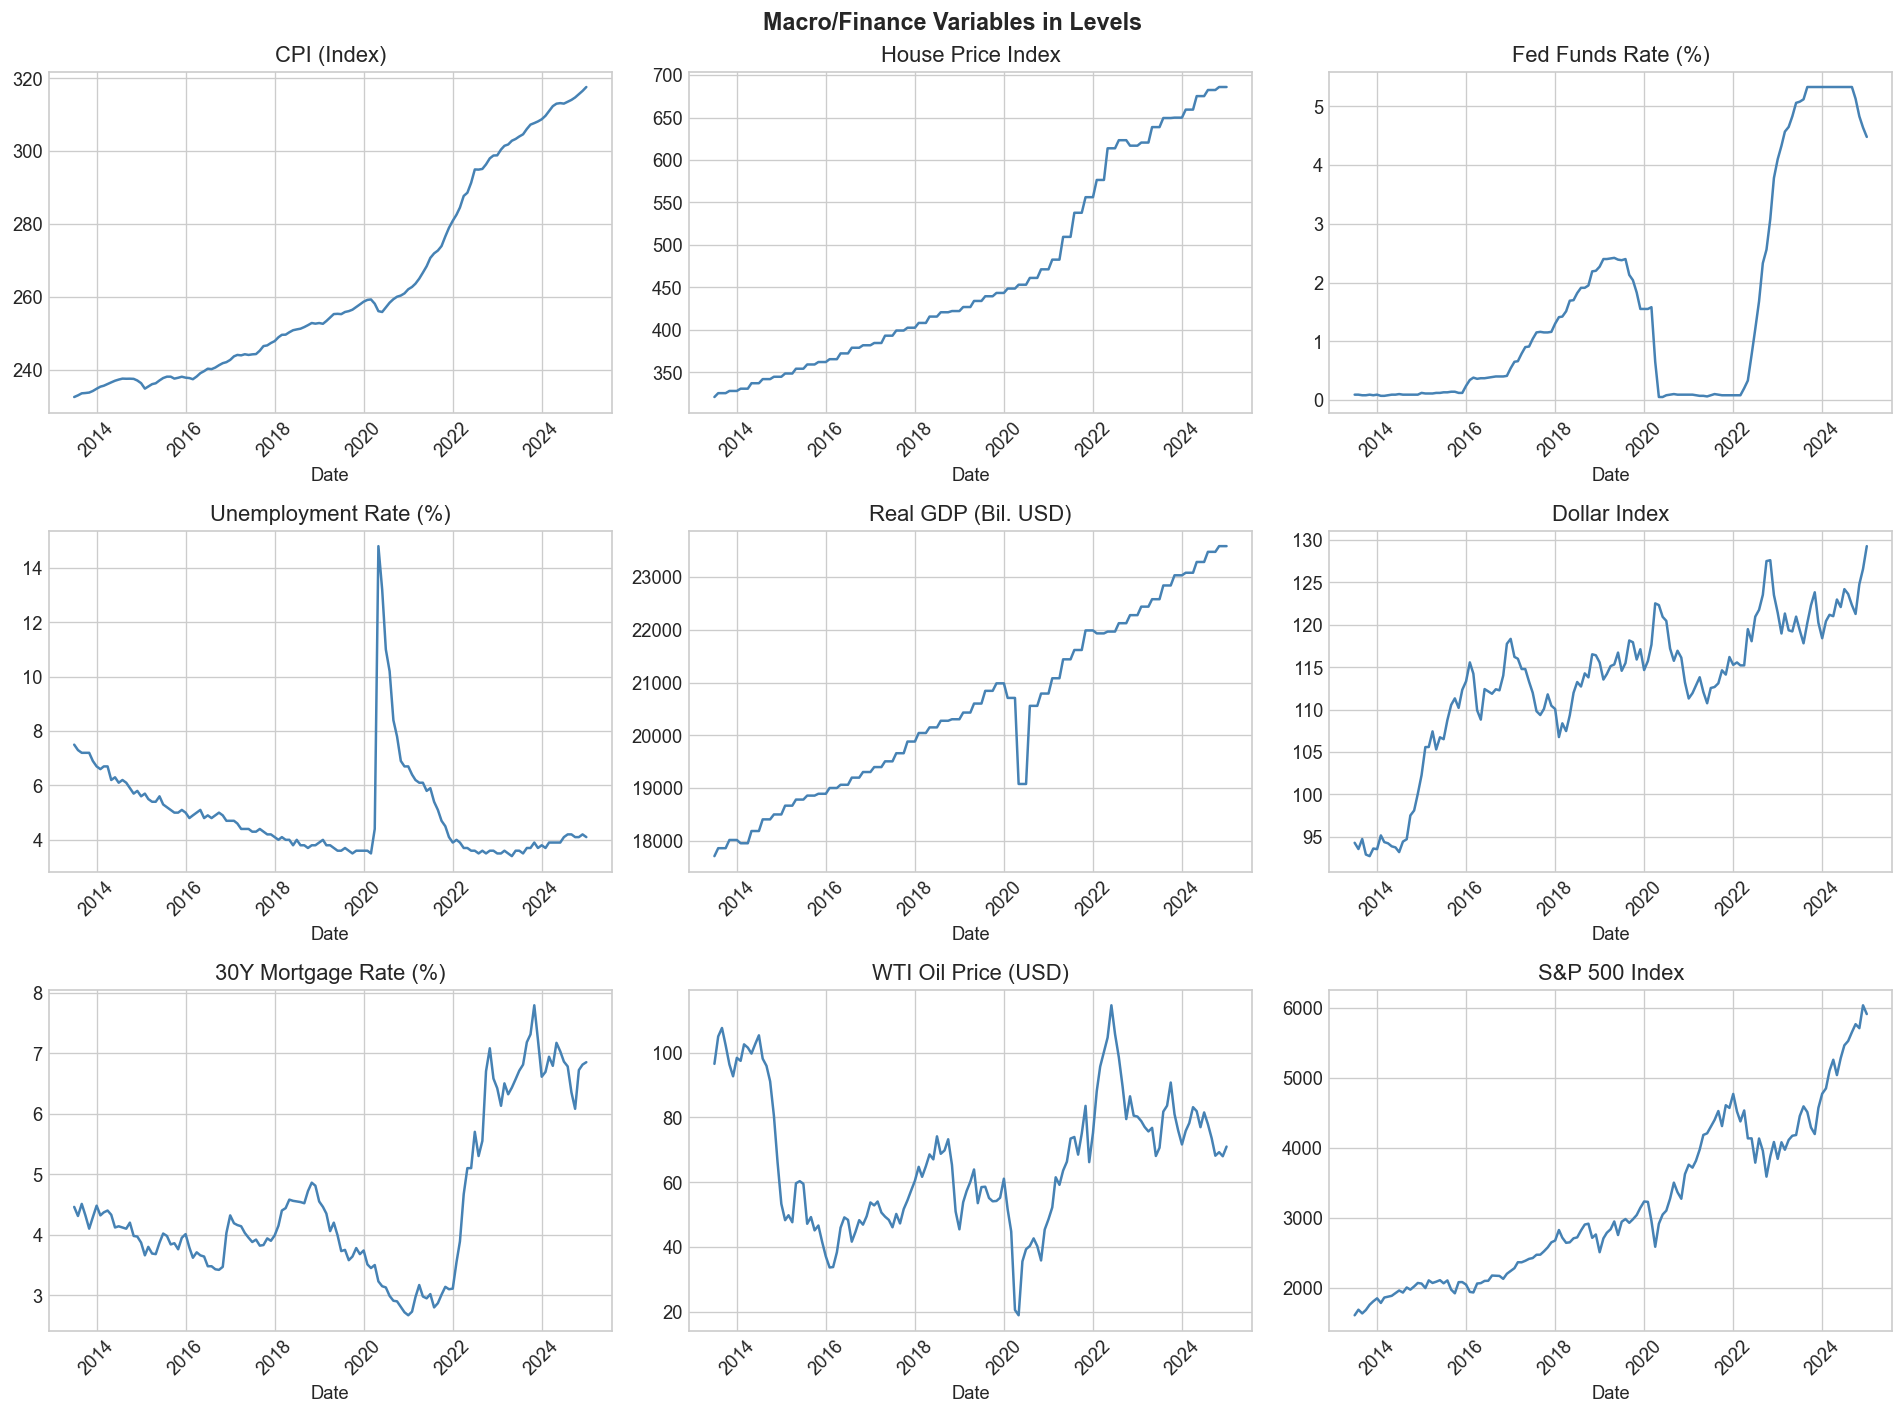

In [29]:
plot_macro_levels(macro_df, "2013-06-01", "2024-12-31")

The macro variables show clear trends over the sample period. The Fed Funds Rate was near zero from 2013 to 2022, with a brief tightening cycle around 2018-2019, before rising sharply during the 2022-2023 tightening cycle. CPI and house prices trended upward throughout, with a clear acceleration during the 2021-2022 inflation episode. Unemployment rose dramatically to around 14% during the COVID-19 shock in 2020 before recovering rapidly. Mortgage rates fell to historic lows around 2020-2021 before rising sharply from 2022 onward. Oil prices were highly volatile with a dramatic drop in 2020, while the S&P 500 trended strongly upward throughout the period despite a brief decline in 2020. The Dollar Index strengthened gradually over the sample period.

### 4.2 Time series of macro/finance variables in changes

In [30]:
def plot_macro_changes(macro_df, survey_start, survey_end):

    """Plot time series of 12-month relative changes in macro/finance variables."""
    
    chg_cols = [c for c in macro_df.columns if c.endswith("_chg_12m")]
    labels = {
        "CPI_chg_12m":      "CPI 12m Change (%)",
        "HPI_chg_12m":      "House Price 12m Change (%)",
        "FEDFUNDS_chg_12m": "Fed Funds 12m Change (%)",
        "UNRATE_chg_12m":   "Unemployment 12m Change (%)",
        "GDP_chg_12m":      "Real GDP 12m Change (%)",
        "DOLLAR_chg_12m":   "Dollar 12m Change (%)",
        "MORTGAGE_chg_12m": "Mortgage 12m Change (%)",
        "OIL_chg_12m":      "Oil 12m Change (%)",
        "SP500_chg_12m":    "S&P 500 12m Change (%)",
    }
    df = macro_df.loc[survey_start:survey_end, chg_cols].copy()
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    axes = axes.flatten()
    for ax, col in zip(axes, chg_cols):
        ax.plot(df.index, df[col] * 100, color="steelblue", linewidth=1.5)
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
        ax.set_title(labels.get(col, col))
        ax.set_xlabel("Date")
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    fig.suptitle("Macro/Finance Variables: 12-Month Changes", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

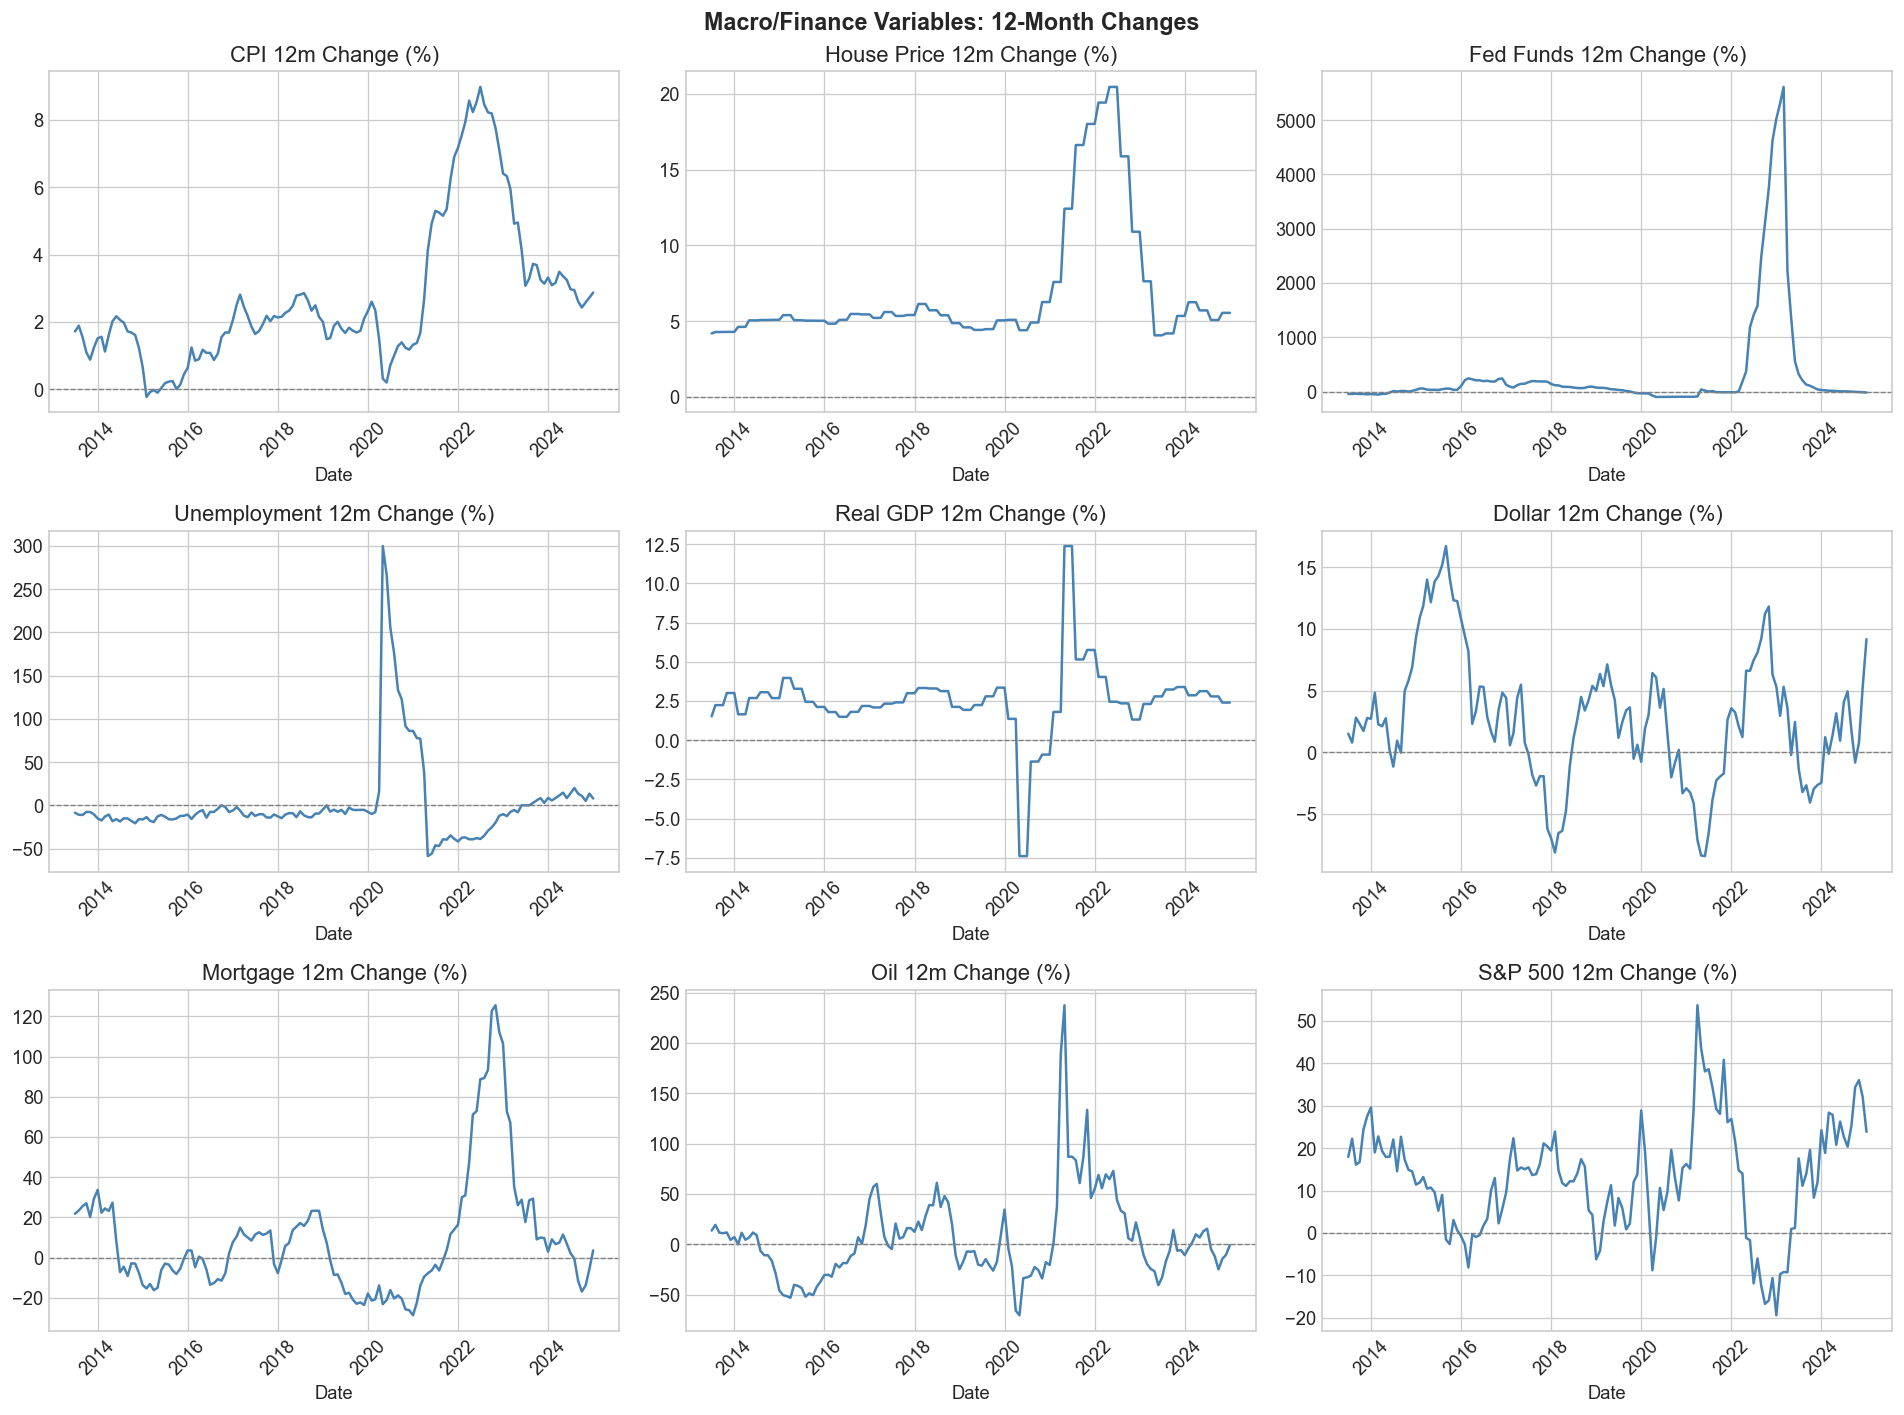

In [31]:
plot_macro_changes(macro_df, "2013-06-01", "2024-12-31")

The 12-month changes highlight the economic shocks during the sample period. CPI inflation peaked at around 8-9% in 2022 before declining. House price growth peaked at nearly 20% in 2022 before falling back to more normal levels. The Fed Funds Rate rose sharply in 2022-2023, reflecting the tightening cycle from near-zero levels. Unemployment rose sharply during the COVID-19 shock in 2020, before recovering rapidly. Mortgage rates rose sharply in 2022, reflecting the rate hiking cycle. Oil prices were volatile throughout, with a large drop in 2020 followed by a sharp rebound. GDP growth turned negative during COVID-19 before recovering strongly in 2021.

### 4.3 Correlation between macro/finance variables and expectations

In [32]:
def compute_correlation_tables(df, target_vars, macro_cols):
    
    """
    For each target variable, display a correlation table with all macro/finance
    variables, sorted by absolute correlation.
    """

    for target in target_vars:
        corrs = (
            df[macro_cols + [target]]
            .corr()[target]
            .drop(target)
            .sort_values(key=abs, ascending=False)
            .rename("Correlation")
            .to_frame()
        )
        corrs.index.name = "Macro Variable"
        print(f"\nCorrelation with {target}:")
        display(corrs.style.format("{:.4f}").background_gradient(cmap="RdBu_r", vmin=-0.2, vmax=0.2))

In [33]:
macro_feature_cols = [c for c in sce.columns if any(
    c.startswith(n) for n in ["CPI","HPI","FEDFUNDS","UNRATE","GDP","DOLLAR","MORTGAGE","OIL","SP500"]
)]

compute_correlation_tables(sce, TARGET_VARS, macro_feature_cols)


Correlation with infl_1y:


,Correlation
Macro Variable,
HPI_chg_12m,0.1319
CPI_chg_12m,0.1178
OIL_chg_12m,0.0887
OIL_level,0.0874
MORTGAGE_chg_12m,0.0762
SP500_level,0.0581
HPI_level,0.0564
GDP_chg_12m,0.0538
CPI_level,0.0494



Correlation with house_price_change:


,Correlation
Macro Variable,
SP500_chg_12m,0.1325
GDP_chg_12m,0.1154
OIL_chg_12m,0.1085
FEDFUNDS_chg_12m,-0.1004
DOLLAR_level,-0.0932
FEDFUNDS_level,-0.0796
UNRATE_chg_12m,-0.0782
MORTGAGE_level,-0.0764
DOLLAR_chg_12m,-0.0620



Correlation with prob_unrate_up:


,Correlation
Macro Variable,
SP500_chg_12m,-0.0793
MORTGAGE_level,0.0562
MORTGAGE_chg_12m,0.0554
FEDFUNDS_chg_12m,0.0532
FEDFUNDS_level,0.0486
OIL_chg_12m,-0.0423
GDP_chg_12m,-0.0421
DOLLAR_level,0.0398
UNRATE_level,-0.0373



Correlation with prob_stocks_up:


,Correlation
Macro Variable,
UNRATE_level,0.0583
CPI_chg_12m,-0.0549
MORTGAGE_chg_12m,-0.0533
MORTGAGE_level,-0.0513
CPI_level,-0.0495
HPI_level,-0.0494
FEDFUNDS_chg_12m,-0.0482
OIL_level,-0.0479
GDP_level,-0.0475


CPI and its 12-month change show the strongest correlations with inflation expectations,
which is intuitive since households likely anchor their forecasts to recent price developments.
The unemployment rate is most correlated with the probability of unemployment increasing.
Stock market returns (S&P 500 12-month change) are most correlated with stock market optimism,
while mortgage rates and house price levels are most correlated with house price expectations.

## Part 5 - Predicting Continuous Expectation Variables
***

This section fits regression models to predict the four continuous expectation variables:
`infl_1y`, `house_price_change`, `prob_unrate_up`, and `prob_stocks_up`. Models are trained
on data prior to 2024 and evaluated on 2024 data. We use 5-fold cross-validation as recommended
for large datasets.

### 5.1 Train/test split

In [34]:
# Split into training (before 2024) and test (2024) sets
train = sce[sce["date"] < "2024-01-01"].copy()
test  = sce[sce["date"] >= "2024-01-01"].copy()

print(f"Training set: {len(train):,} observations ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Test set    : {len(test):,} observations ({test['date'].min().date()} to {test['date'].max().date()})")

Training set: 134,304 observations (2013-06-01 to 2023-12-31)
Test set    : 11,586 observations (2024-01-02 to 2024-12-31)


### 5.2 Feature sets

We use two feature sets for each model:
1. **Macro-only**: only the macro/finance variables
2. **Macro + individual**: macro/finance variables combined with stable demographic and
literacy variables. Categorical variables (`educ`) are encoded using one-hot encoding
following Lecture 10.

In [35]:
# Macro/finance feature columns
MACRO_COLS = [c for c in sce.columns if any(
    c.startswith(n) for n in ["CPI", "HPI", "FEDFUNDS", "UNRATE", "GDP",
                               "DOLLAR", "MORTGAGE", "OIL", "SP500"]
)]

# Continuous individual-level variables
INDIV_CONT_COLS = [
    "age_init", "female", "hispanic", "black",
    "owner", "couple", "num_kids", "hh_inc_bin_rank", "working",
    "num_lit_q1_correct", "num_lit_q2_correct",
    "num_lit_q3_correct", "num_lit_q5_correct"
]

# Categorical individual-level variables (need one-hot encoding)
INDIV_CAT_COLS = ["educ"]

# Build feature matrices for train and test
X_train_macro = train[MACRO_COLS].values
X_test_macro  = test[MACRO_COLS].values

# Fit encoder on training data only to avoid data leakage
ohe = OneHotEncoder(sparse_output=False, drop="first")
ohe.fit(train[INDIV_CAT_COLS])

X_train_full = np.hstack([
    train[MACRO_COLS].values,
    train[INDIV_CONT_COLS].values,
    ohe.transform(train[INDIV_CAT_COLS])
])

X_test_full = np.hstack([
    test[MACRO_COLS].values,
    test[INDIV_CONT_COLS].values,
    ohe.transform(test[INDIV_CAT_COLS])
])

print(f"Macro-only features    : {X_train_macro.shape[1]} columns")
print(f"Macro + indiv features : {X_train_full.shape[1]} columns")

Macro-only features    : 18 columns
Macro + indiv features : 34 columns


### 5.3 Helper functions

We define reusable functions for model evaluation and plotting to avoid code duplication.

In [36]:
def evaluate_regression(model, X_test, y_test):

    """Compute RMSE and R2 on the test sample."""
    
    y_pred = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    return rmse, r2

In [37]:
def plot_timeseries_predictions(sce, train, test, model, X_all, target, model_name, feature_label):
    
    """
    Plot monthly average actual vs predicted values with train/test split marker.
    """
    
    df_plot = sce.copy()
    df_plot["predicted"] = model.predict(X_all)

    monthly_actual    = sce.groupby(sce["date"].dt.to_period("M"))[target].mean()
    monthly_predicted = df_plot.groupby(df_plot["date"].dt.to_period("M"))["predicted"].mean()

    monthly_actual.index    = monthly_actual.index.to_timestamp()
    monthly_predicted.index = monthly_predicted.index.to_timestamp()

    split_date = pd.Timestamp("2024-01-01")

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(monthly_actual.index, monthly_actual.values,
            color="black", linewidth=1.5, label="Actual")
    ax.plot(monthly_predicted.index, monthly_predicted.values,
            color="steelblue", linewidth=1.5, linestyle="--", label="Predicted")
    ax.axvline(split_date, color="red", linestyle=":", linewidth=1.2, label="Train/Test split")
    ax.set_xlabel("Date")
    ax.set_ylabel(target)
    ax.set_title(f"{model_name} ({feature_label}) - {target}")
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()

### 5.4 Linear Regression

Linear regression has no hyperparameters and does not require feature scaling.
We fit the model using only macro variables first, then add individual-level variables.

In [38]:
# Fit OLS for each target variable using macro-only and macro+indiv feature sets
results = {}

for target in TARGET_VARS:
    results[target] = {}
    y_train = train[target].values
    y_test  = test[target].values

    for label, X_tr, X_te in [
        ("Macro only",   X_train_macro, X_test_macro),
        ("Macro + indiv", X_train_full, X_test_full),
    ]:
        
        model = LinearRegression()
        model.fit(X_tr, y_train)
        rmse, r2 = evaluate_regression(model, X_te, y_test)
        results[target][f"OLS ({label})"] = {"RMSE": rmse, "R2": r2, "model": model}
        print(f"{target} | OLS | {label} -> RMSE={rmse:.4f}, R2={r2:.4f}")

infl_1y | OLS | Macro only -> RMSE=9.2877, R2=-0.0111
infl_1y | OLS | Macro + indiv -> RMSE=9.0239, R2=0.0455
house_price_change | OLS | Macro only -> RMSE=8.4617, R2=-0.0027
house_price_change | OLS | Macro + indiv -> RMSE=8.2615, R2=0.0442
prob_unrate_up | OLS | Macro only -> RMSE=22.3806, R2=-0.0052
prob_unrate_up | OLS | Macro + indiv -> RMSE=21.8891, R2=0.0385
prob_stocks_up | OLS | Macro only -> RMSE=23.1648, R2=-0.0183
prob_stocks_up | OLS | Macro + indiv -> RMSE=21.6510, R2=0.1105


Linear regression serves as a baseline. It requires no hyperparameter tuning and no feature
scaling. The model is estimated by minimizing the sum of squared residuals.

### 5.5 Ridge Regression

Ridge regression adds an L2 penalty to the loss function, shrinking coefficients toward zero.
It requires feature scaling and has one hyperparameter: the penalty strength alpha.
We use RidgeCV with 5-fold cross-validation to select the optimal alpha.

In [39]:
# Fit Ridge regression with cross-validated alpha for each target variable
alphas = np.logspace(-3, 5, 30)

for target in TARGET_VARS:
    y_train = train[target].values
    y_test  = test[target].values

    for label, X_tr, X_te in [
        ("Macro only",   X_train_macro, X_test_macro),
        ("Macro + indiv", X_train_full, X_test_full),
    ]:
        
        model = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5, scoring="neg_root_mean_squared_error"))
        model.fit(X_tr, y_train)

        best_alpha = model.named_steps["ridgecv"].alpha_
        best_score = model.named_steps["ridgecv"].best_score_
        
        rmse, r2 = evaluate_regression(model, X_te, y_test)
        results[target][f"Ridge ({label})"] = {"RMSE": rmse, "R2": r2, "model": model}

        print(f"{target} | Ridge | {label} -> alpha = {best_alpha:.4f}, CV RMSE = {-best_score:.4f}, RMSE = {rmse:.4f}, R2 = {r2:.4f}")

infl_1y | Ridge | Macro only -> alpha = 14873.5211, CV RMSE = 8.3452, RMSE = 9.2854, R2 = -0.0107
infl_1y | Ridge | Macro + indiv -> alpha = 14873.5211, CV RMSE = 8.0327, RMSE = 9.0135, R2 = 0.0477
house_price_change | Ridge | Macro only -> alpha = 52983.1691, CV RMSE = 7.5468, RMSE = 8.4908, R2 = -0.0096
house_price_change | Ridge | Macro + indiv -> alpha = 28072.1620, CV RMSE = 7.3621, RMSE = 8.2677, R2 = 0.0427
prob_unrate_up | Ridge | Macro only -> alpha = 100000.0000, CV RMSE = 22.1661, RMSE = 22.3172, R2 = 0.0005
prob_unrate_up | Ridge | Macro + indiv -> alpha = 100000.0000, CV RMSE = 22.0948, RMSE = 21.9269, R2 = 0.0351
prob_stocks_up | Ridge | Macro only -> alpha = 52983.1691, CV RMSE = 22.1496, RMSE = 23.0580, R2 = -0.0089
prob_stocks_up | Ridge | Macro + indiv -> alpha = 28072.1620, CV RMSE = 21.3063, RMSE = 21.5944, R2 = 0.1151


### 5.6 Ridge validation curves

In [40]:
def plot_ridge_validation_curve(X_train, y_train, alphas, title):

    """Plot Ridge validation curve showing RMSE vs penalty strength."""
    
    pipe = make_pipeline(StandardScaler(), Ridge())
    train_scores, val_scores = validation_curve(
        pipe, X_train, y_train,
        param_name="ridge__alpha",
        param_range=alphas,
        scoring="neg_root_mean_squared_error",
        cv=5
    )
    train_rmse = -train_scores.mean(axis=1)
    val_rmse   = -val_scores.mean(axis=1)
    plt.figure(figsize=(7, 4))
    plt.semilogx(alphas, train_rmse, color="black", marker="x", ms=4, label="Training")
    plt.semilogx(alphas, val_rmse, color="steelblue", marker="o", ms=4, label="Validation")
    plt.xlabel("Alpha (penalty strength)")
    plt.ylabel("Cross-validated RMSE")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

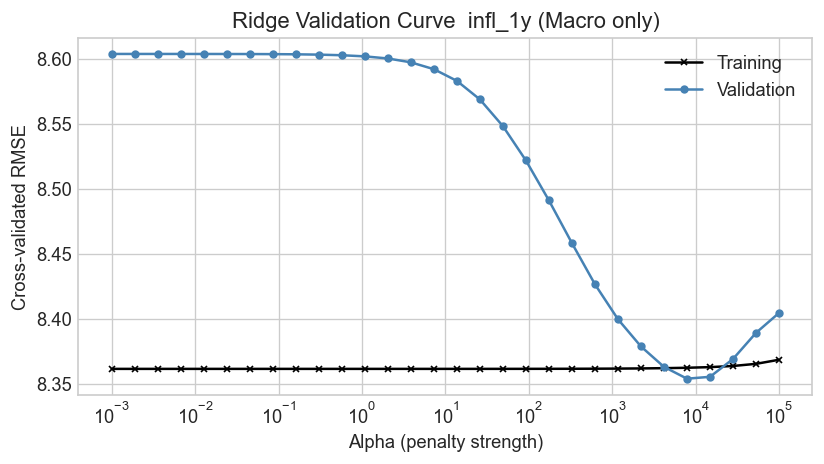

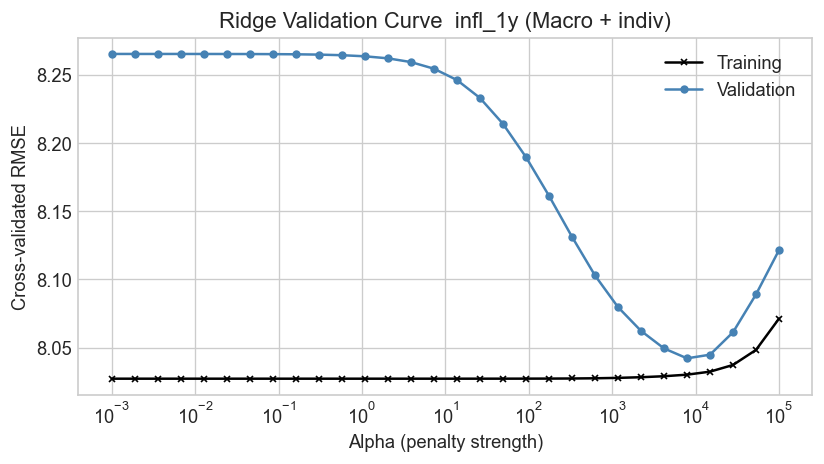

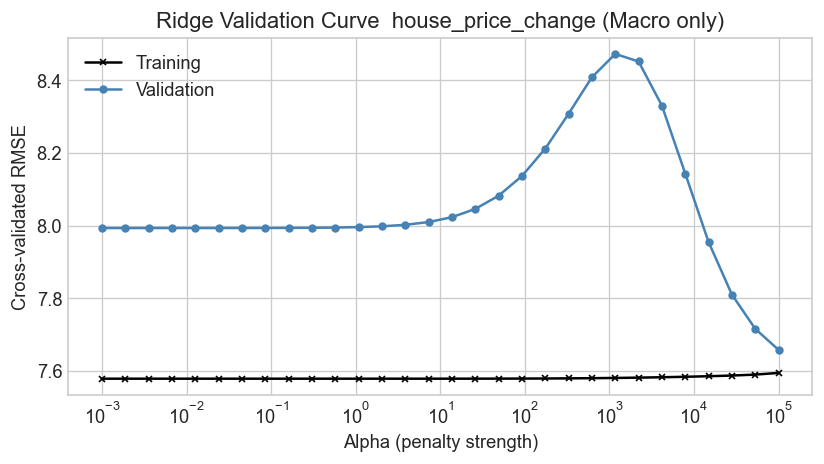

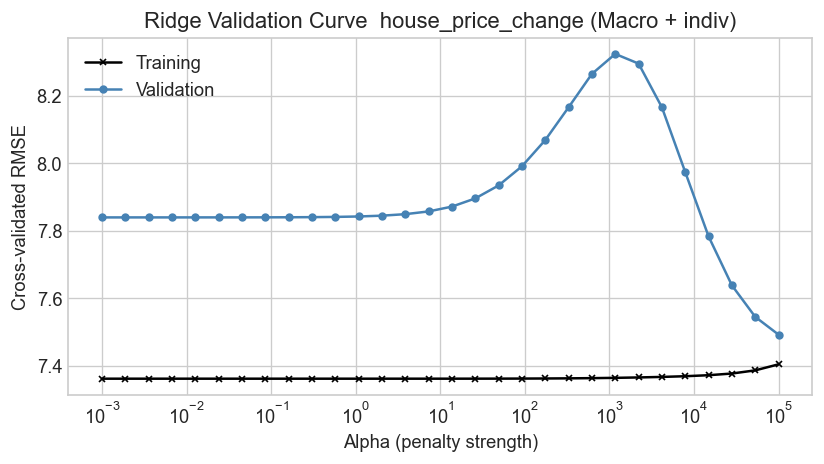

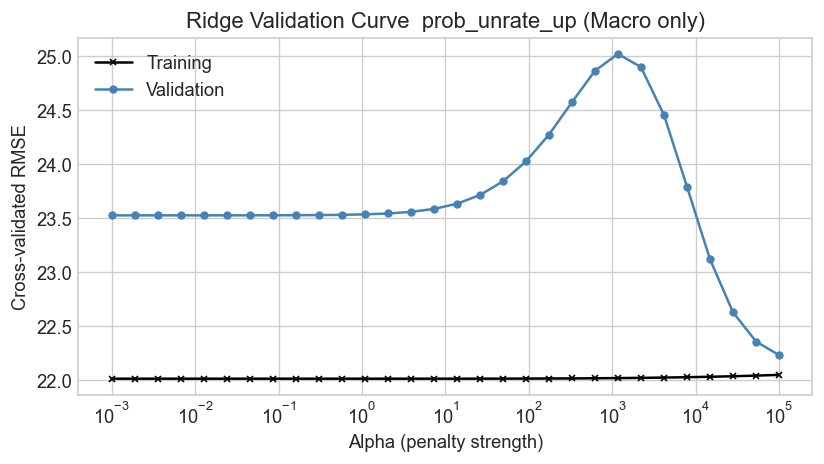

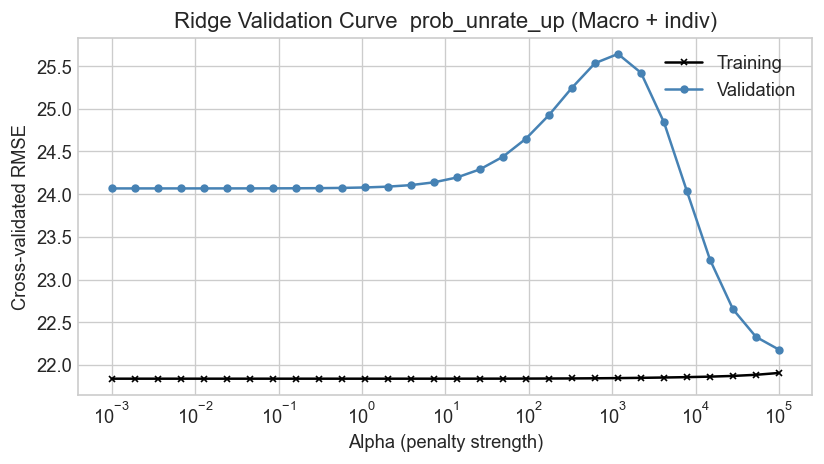

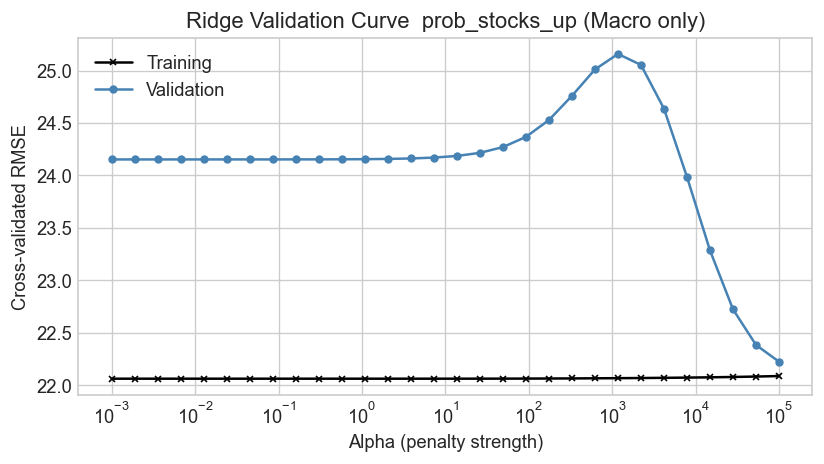

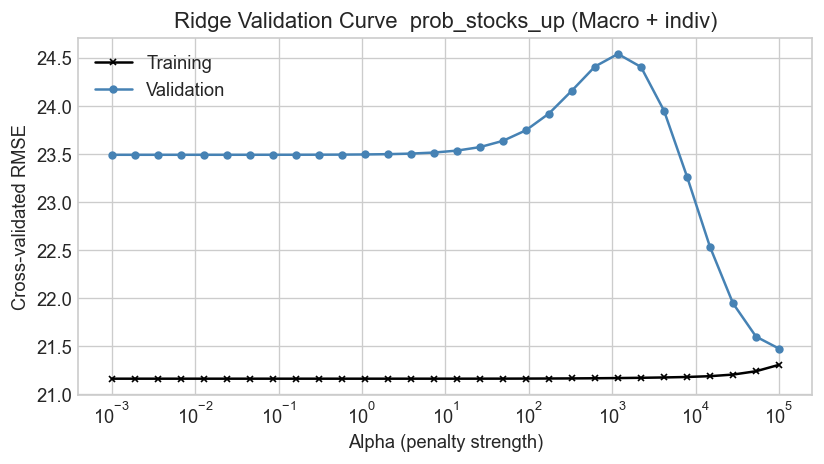

In [41]:
for target in TARGET_VARS:
    y_train = train[target].values
    for label, X_tr in [("Macro only", X_train_macro), ("Macro + indiv", X_train_full)]:
        plot_ridge_validation_curve(X_tr, y_train, alphas,
            f"Ridge Validation Curve  {target} ({label})")

The Ridge validation curves show that for all but `prob_unrate_up`, the optimal alpha lies within the search grid. Alpha for `prob_unrate_up` is at the upper bound of the search grid, suggesting that the optimal value might be located beyond the grid. While strong regularisation appears beneficial, the validation curve does not contain a clear plateau and continues to decline at higher values of alpha, suggesting that the model is sensitive to the choice of alpha.

### 5.7 Lasso Regression

Lasso regression adds an L1 penalty which can shrink coefficients to exactly zero, effectively
performing feature selection. It requires feature scaling and has one hyperparameter: alpha.
We use LassoCV with 5-fold cross-validation.

In [42]:
# Fit Lasso regression with cross-validated alpha for each target variable
for target in TARGET_VARS:
    y_train = train[target].values
    y_test  = test[target].values

    for label, X_tr, X_te in [
        ("Macro only",    X_train_macro, X_test_macro),
        ("Macro + indiv", X_train_full,  X_test_full),
    ]:
        model = make_pipeline(
            StandardScaler(),
            LassoCV(alphas=alphas, cv=5, max_iter=10000, selection="random")
        )
        model.fit(X_tr, y_train)
        best_alpha = model.named_steps["lassocv"].alpha_
        lasso_step = model.named_steps["lassocv"]
        alpha_idx = np.argmin(np.abs(lasso_step.alphas_ - lasso_step.alpha_))
        cv_rmse = np.sqrt(lasso_step.mse_path_[alpha_idx, :]).mean()
        rmse, r2 = evaluate_regression(model, X_te, y_test)
        results[target][f"Lasso ({label})"] = {"RMSE": rmse, "R2": r2, "model": model}
        print(f"{target} | Lasso | {label} -> alpha = {best_alpha:.4f}, CV RMSE = {cv_rmse:.4f}, RMSE = {rmse:.4f}, R2 = {r2:.4f}")

infl_1y | Lasso | Macro only -> alpha = 0.0452, CV RMSE = 8.3506, RMSE = 9.2951, R2 = -0.0128
infl_1y | Lasso | Macro + indiv -> alpha = 0.0452, CV RMSE = 8.0387, RMSE = 9.0235, R2 = 0.0456
house_price_change | Lasso | Macro only -> alpha = 0.0853, CV RMSE = 7.5677, RMSE = 8.4715, R2 = -0.0050
house_price_change | Lasso | Macro + indiv -> alpha = 0.0853, CV RMSE = 7.3814, RMSE = 8.2585, R2 = 0.0449
prob_unrate_up | Lasso | Macro only -> alpha = 0.5736, CV RMSE = 22.1420, RMSE = 22.3273, R2 = -0.0004
prob_unrate_up | Lasso | Macro + indiv -> alpha = 0.3039, CV RMSE = 22.0963, RMSE = 21.9290, R2 = 0.0349
prob_stocks_up | Lasso | Macro only -> alpha = 0.1610, CV RMSE = 22.1772, RMSE = 22.9926, R2 = -0.0032
prob_stocks_up | Lasso | Macro + indiv -> alpha = 0.1610, CV RMSE = 21.3153, RMSE = 21.4816, R2 = 0.1243


### 5.8 Lasso validation curves

In [43]:
def plot_lasso_validation_curve(X_train, y_train, alphas, title):

    """Plot Lasso validation curve showing RMSE vs penalty strength."""
    
    pipe = make_pipeline(StandardScaler(), Lasso(max_iter=10000))
    train_scores, val_scores = validation_curve(
        pipe, X_train, y_train,
        param_name="lasso__alpha",
        param_range=alphas,
        scoring="neg_root_mean_squared_error",
        cv=5
    )
    train_rmse = -train_scores.mean(axis=1)
    val_rmse   = -val_scores.mean(axis=1)
    plt.figure(figsize=(7, 4))
    plt.semilogx(alphas, train_rmse, color="black", marker="x", ms=4, label="Training")
    plt.semilogx(alphas, val_rmse, color="steelblue", marker="o", ms=4, label="Validation")
    plt.xlabel("Alpha (penalty strength)")
    plt.ylabel("Cross-validated RMSE")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

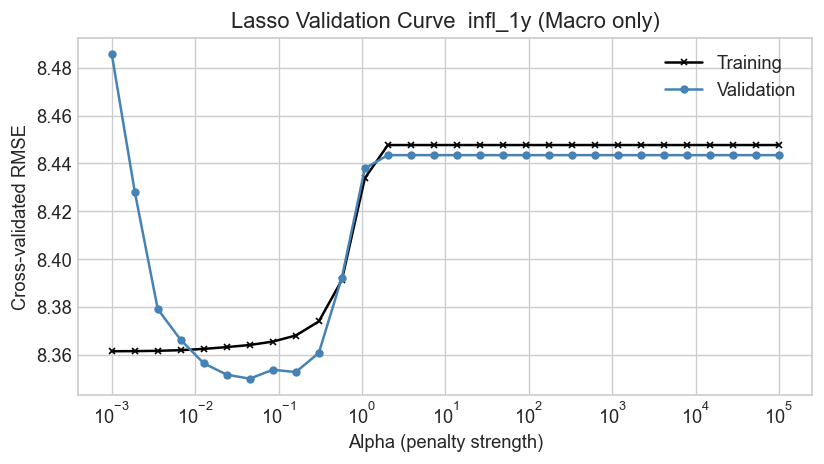

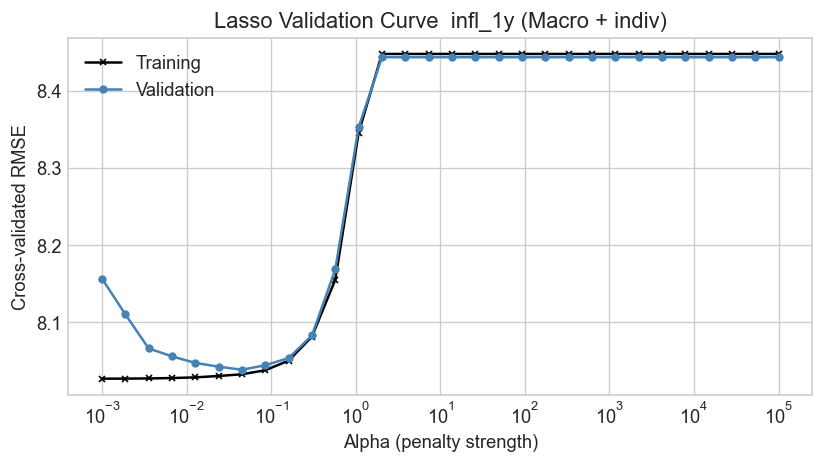

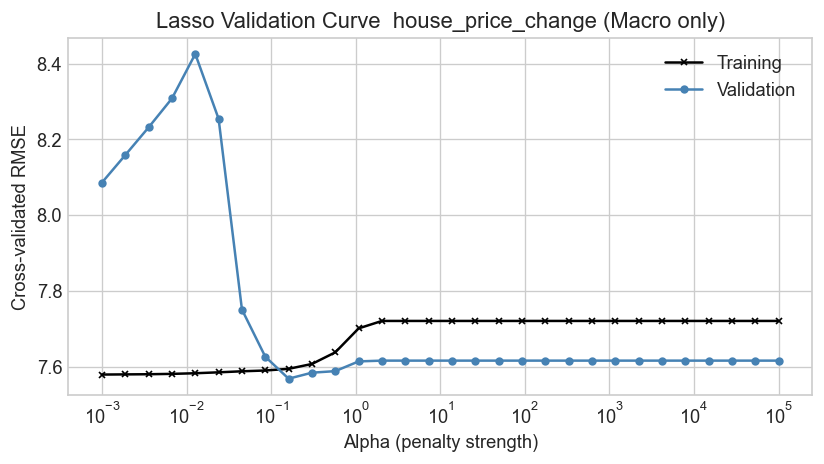

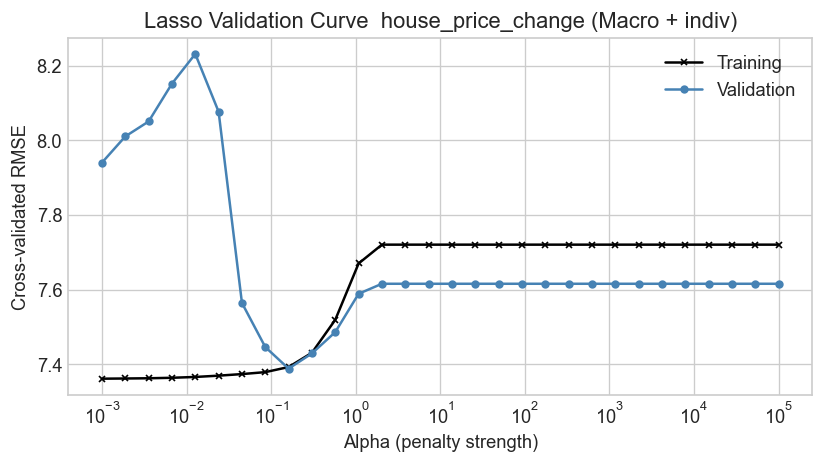

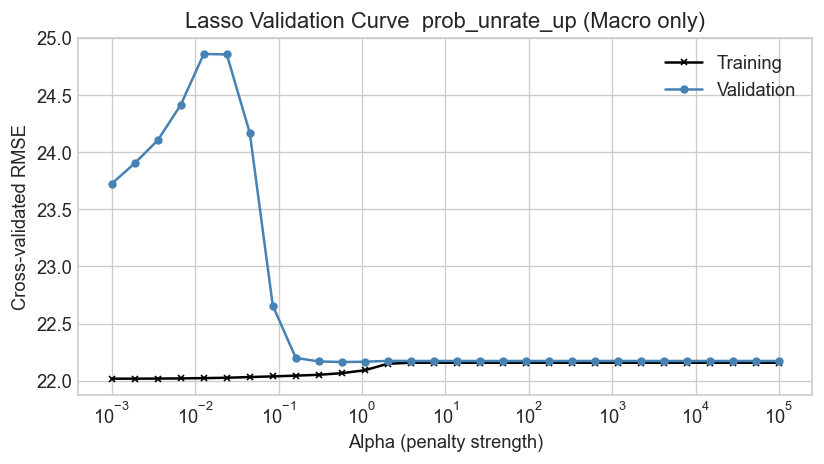

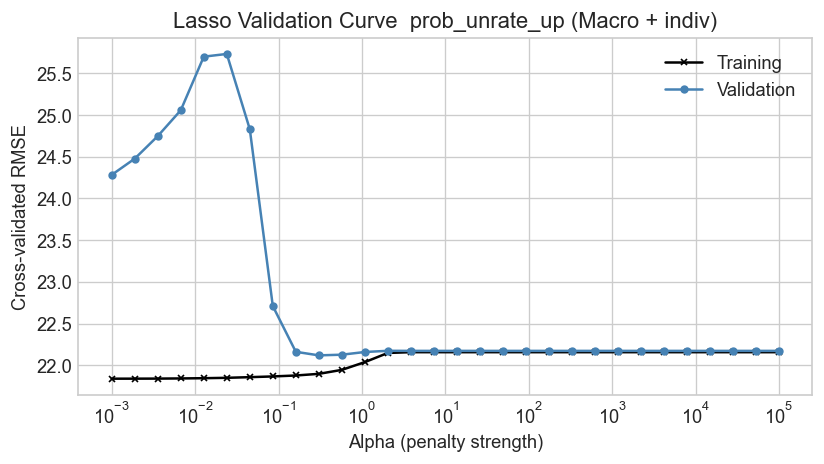

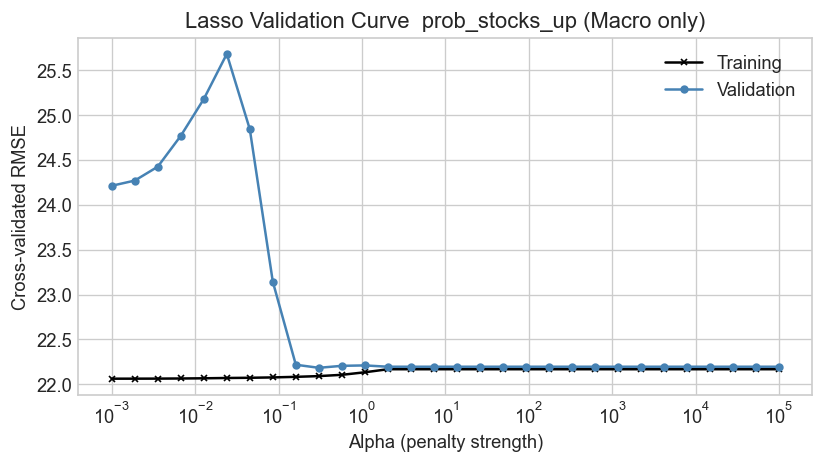

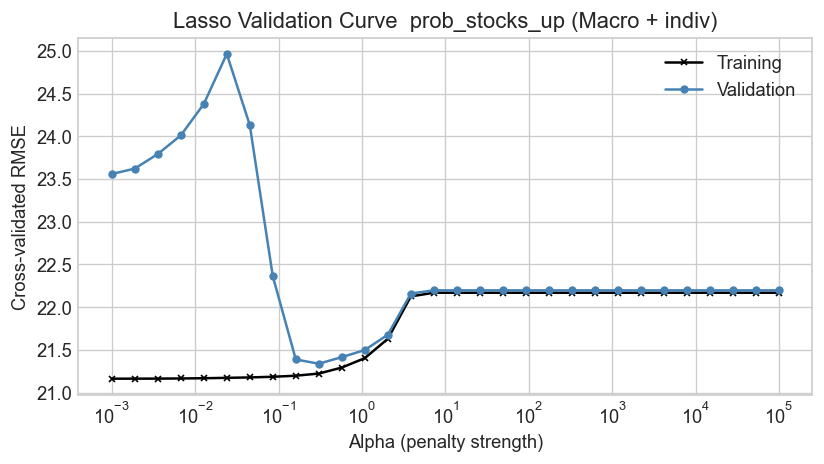

In [44]:
#Plotting Lasso validation curves for each target variable and feature set
for target in TARGET_VARS:
    y_train = train[target].values
    for label, X_tr in [("Macro only", X_train_macro), ("Macro + indiv", X_train_full)]:
        plot_lasso_validation_curve(X_tr, y_train, alphas,
            f"Lasso Validation Curve  {target} ({label})")

The Lasso validation curves show a clear optimal alpha around 10⁻¹ to 10⁰ for all four targets, where validation RMSE is minimised before rising again at higher penalty strengths. Unlike Ridge, the Lasso curves show a more pronounced U-shape, making the optimal alpha easier to identify. At very low alpha values, training and validation RMSE diverge slightly, suggesting mild overfitting, while at high alpha values the model is over-regularised and underfits the data.

### 5.9 Decision Tree Regressor 

Decision trees partition the feature space recursively and can capture non-linear
relationships. They do not require feature scaling. The key hyperparameter is `max_depth`
which controls the complexity of the tree. We use 5-fold cross-validation to select
the optimal depth.

In [45]:
# Fit Decision Tree with cross-validated max_depth for each target variable
depths = np.arange(1, 11)

for target in TARGET_VARS:
    y_train = train[target].values
    y_test  = test[target].values

    for label, X_tr, X_te in [
        ("Macro only",   X_train_macro, X_test_macro),
        ("Macro + indiv", X_train_full, X_test_full),
    ]:
        val_rmses = []
        for d in depths:
            scores = cross_validate(
                DecisionTreeRegressor(max_depth=d, random_state=42),
                X_tr, y_train,
                scoring="neg_root_mean_squared_error",
                cv=5
            )
            val_rmses.append(-scores["test_score"].mean())

        best_idx     = np.argmin(val_rmses)
        best_depth   = depths[best_idx]
        best_cv_rmse = val_rmses[best_idx]

        model = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
        model.fit(X_tr, y_train)
        rmse, r2 = evaluate_regression(model, X_te, y_test)
        results[target][f"DecisionTree ({label})"] = {"RMSE": rmse, "R2": r2, "model": model}
        print(f"{target} | DecisionTree | {label} -> depth = {best_depth}, CV RMSE = {best_cv_rmse:.4f}, RMSE = {rmse:.4f}, R2 = {r2:.4f}")

infl_1y | DecisionTree | Macro only -> depth = 1, CV RMSE = 8.4141, RMSE = 9.2434, R2 = -0.0015
infl_1y | DecisionTree | Macro + indiv -> depth = 5, CV RMSE = 8.1704, RMSE = 9.0235, R2 = 0.0456
house_price_change | DecisionTree | Macro only -> depth = 4, CV RMSE = 7.6081, RMSE = 8.5149, R2 = -0.0154
house_price_change | DecisionTree | Macro + indiv -> depth = 2, CV RMSE = 7.5039, RMSE = 8.5708, R2 = -0.0287
prob_unrate_up | DecisionTree | Macro only -> depth = 3, CV RMSE = 22.1960, RMSE = 22.3958, R2 = -0.0066
prob_unrate_up | DecisionTree | Macro + indiv -> depth = 1, CV RMSE = 22.4916, RMSE = 22.0924, R2 = 0.0205
prob_stocks_up | DecisionTree | Macro only -> depth = 1, CV RMSE = 22.2110, RMSE = 23.1685, R2 = -0.0186
prob_stocks_up | DecisionTree | Macro + indiv -> depth = 4, CV RMSE = 21.4854, RMSE = 21.5934, R2 = 0.1152


### 5.10 Time series plots - Actual vs Predicted

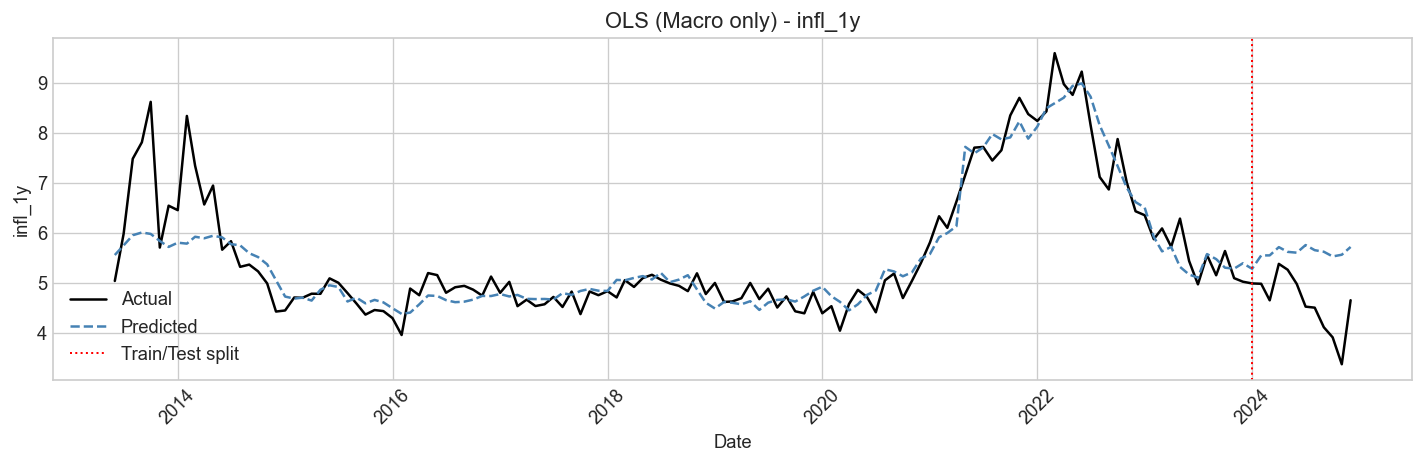

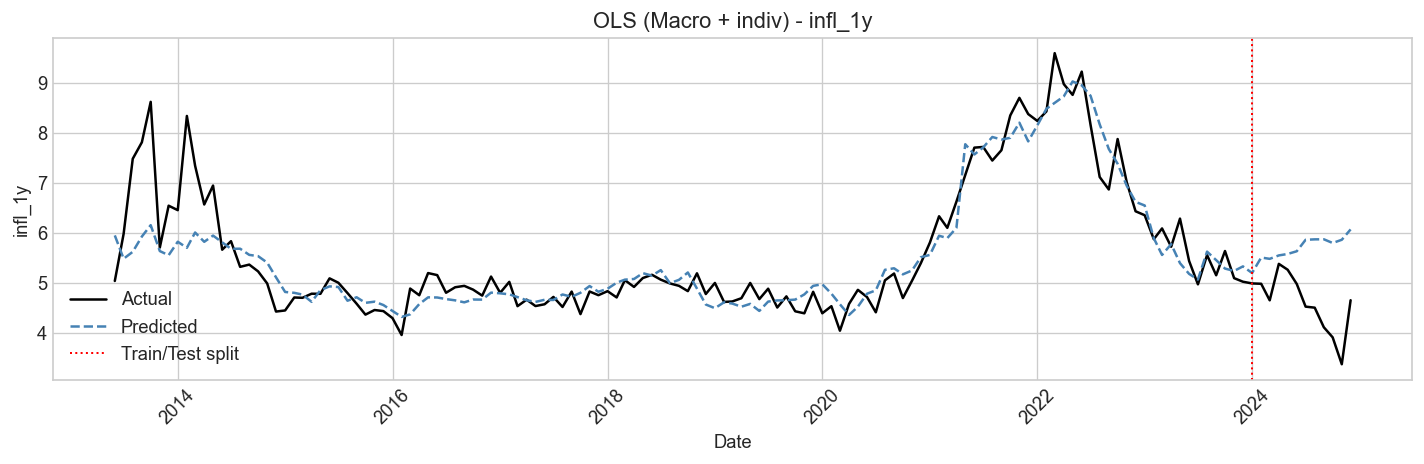

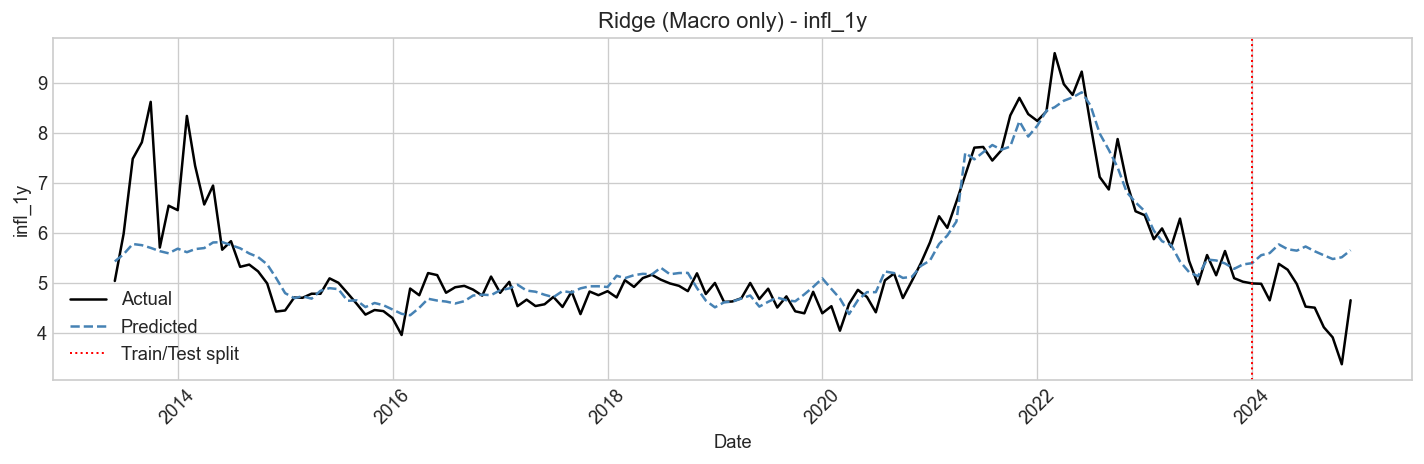

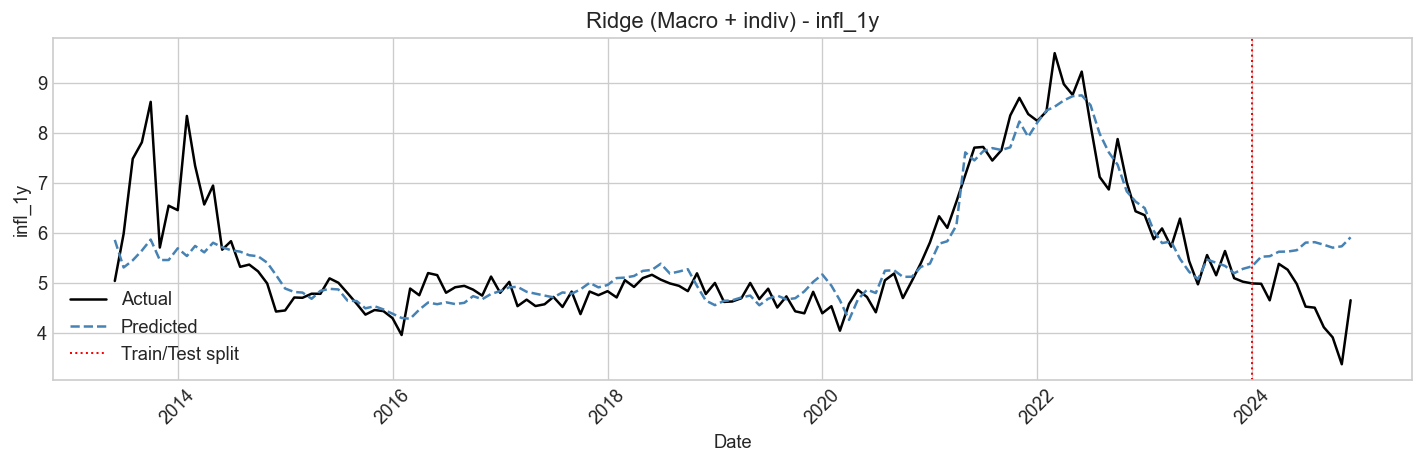

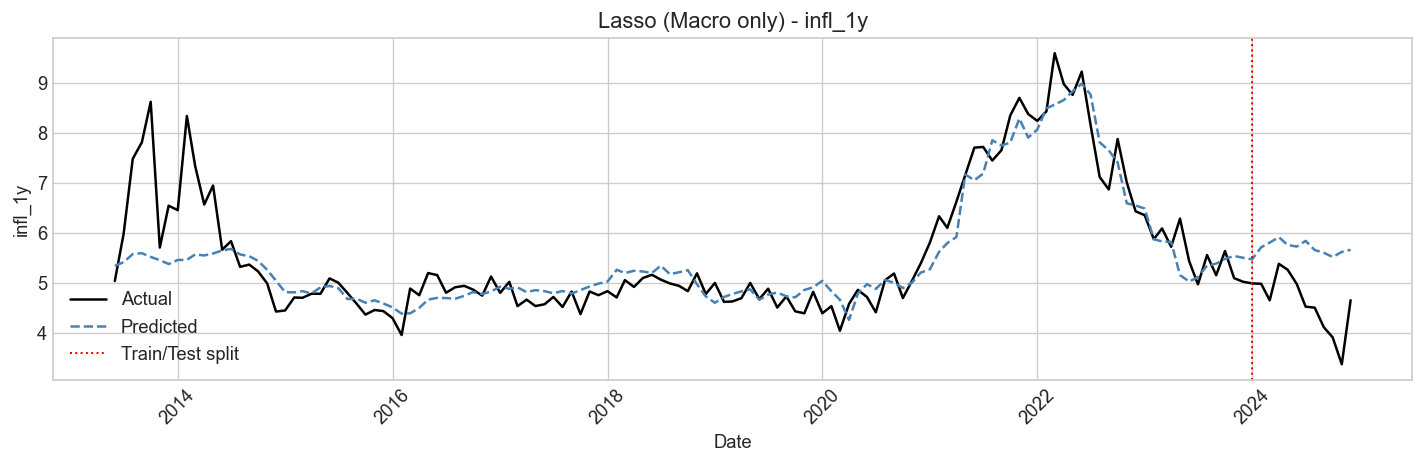

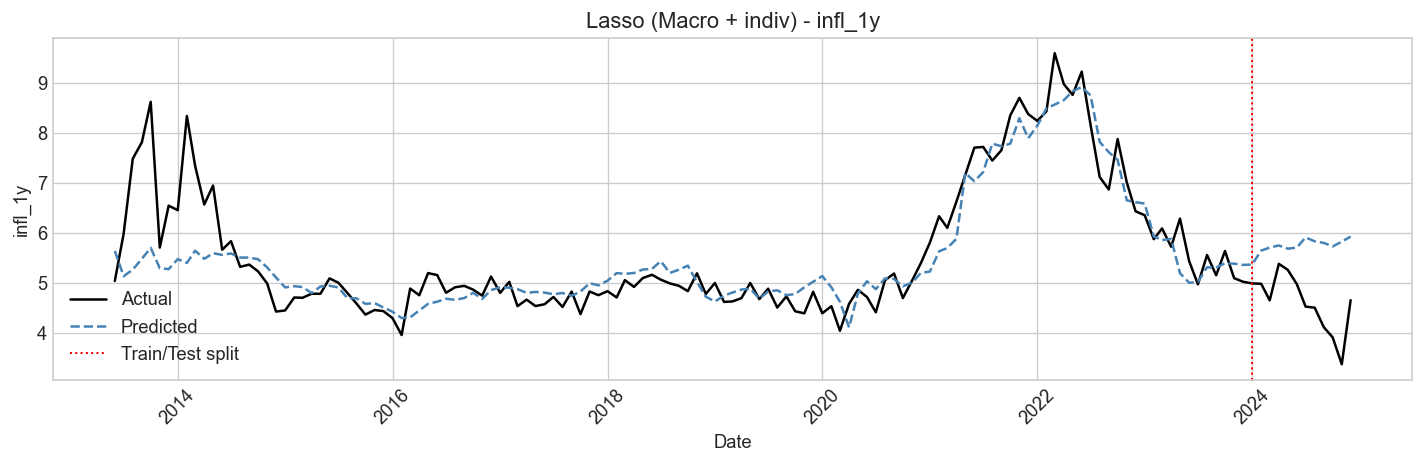

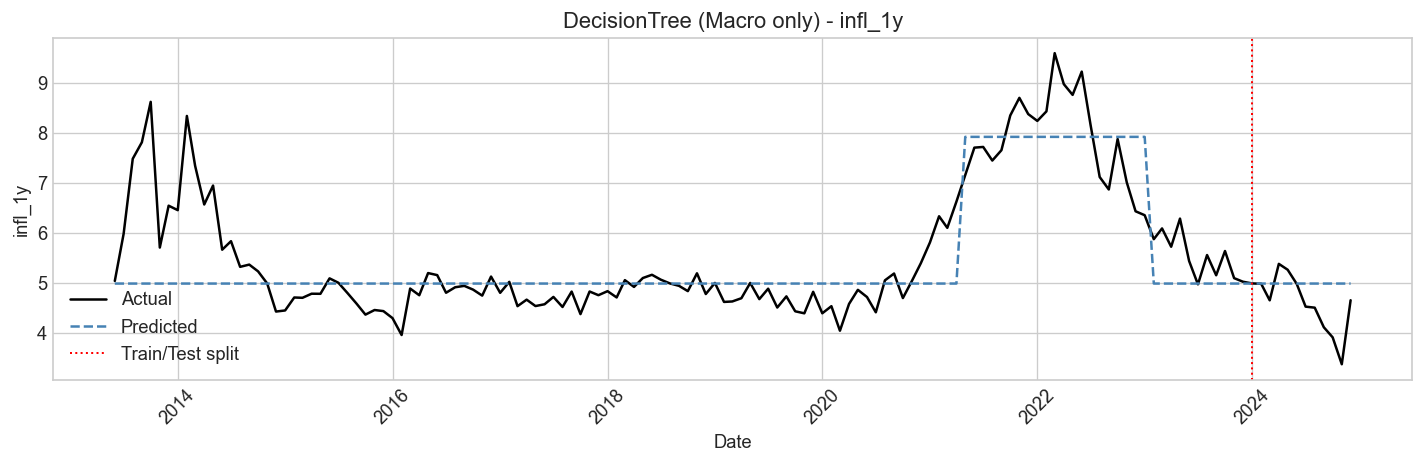

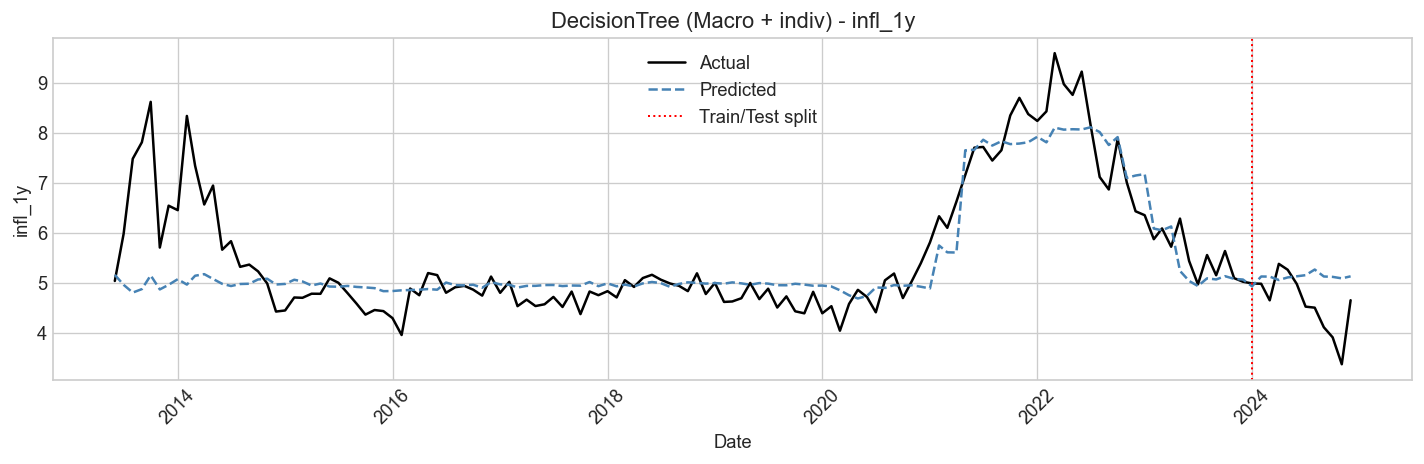

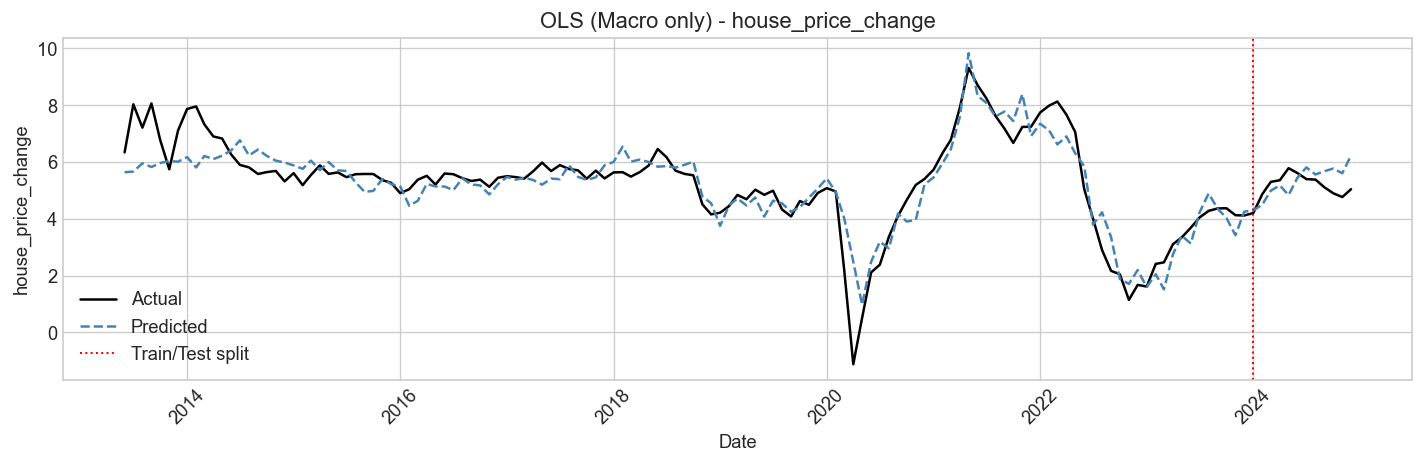

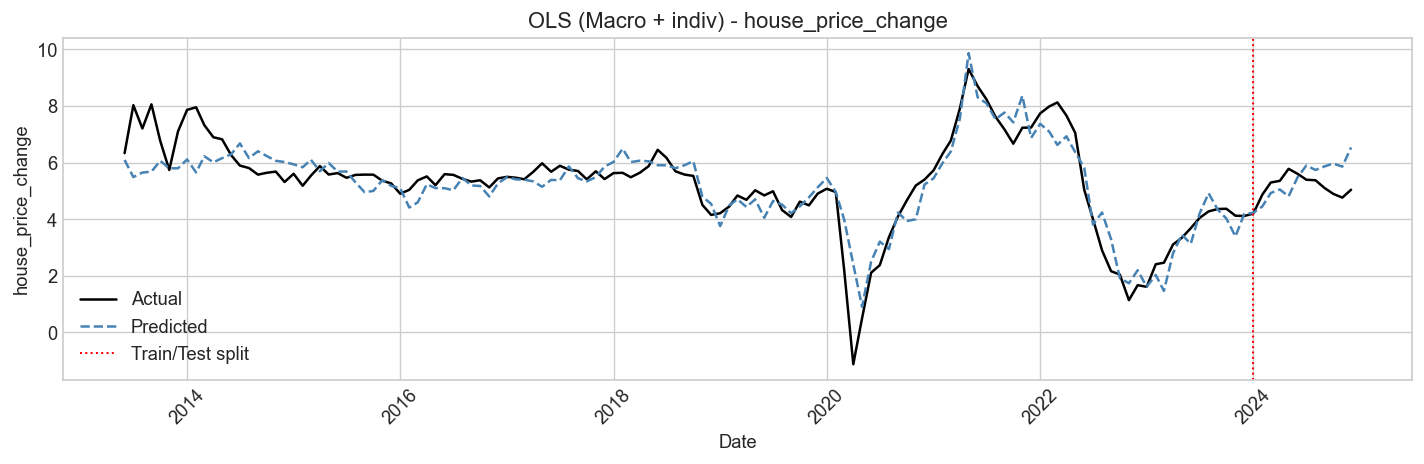

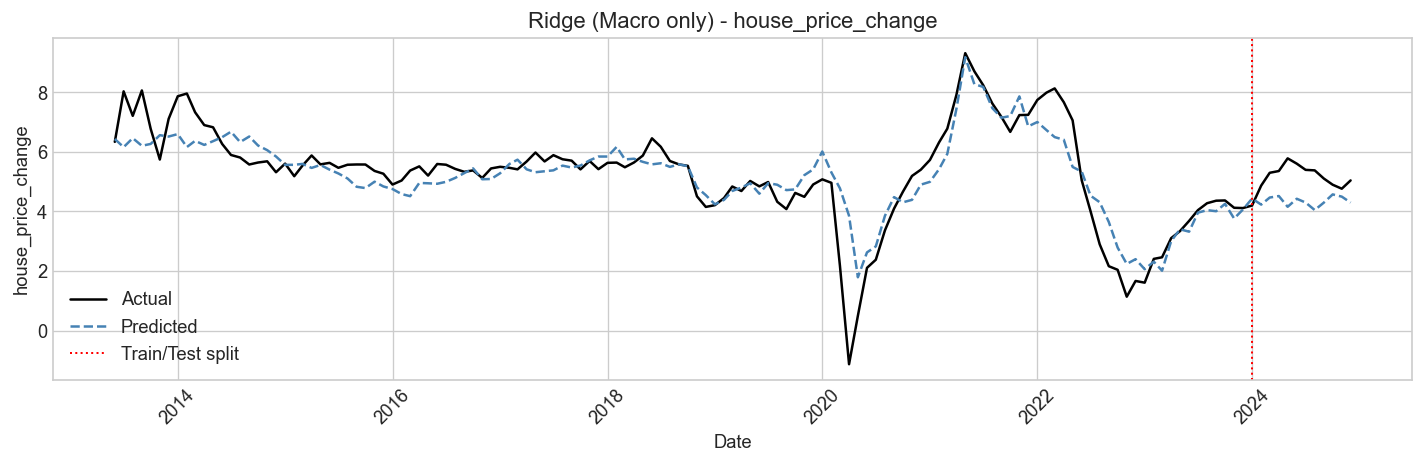

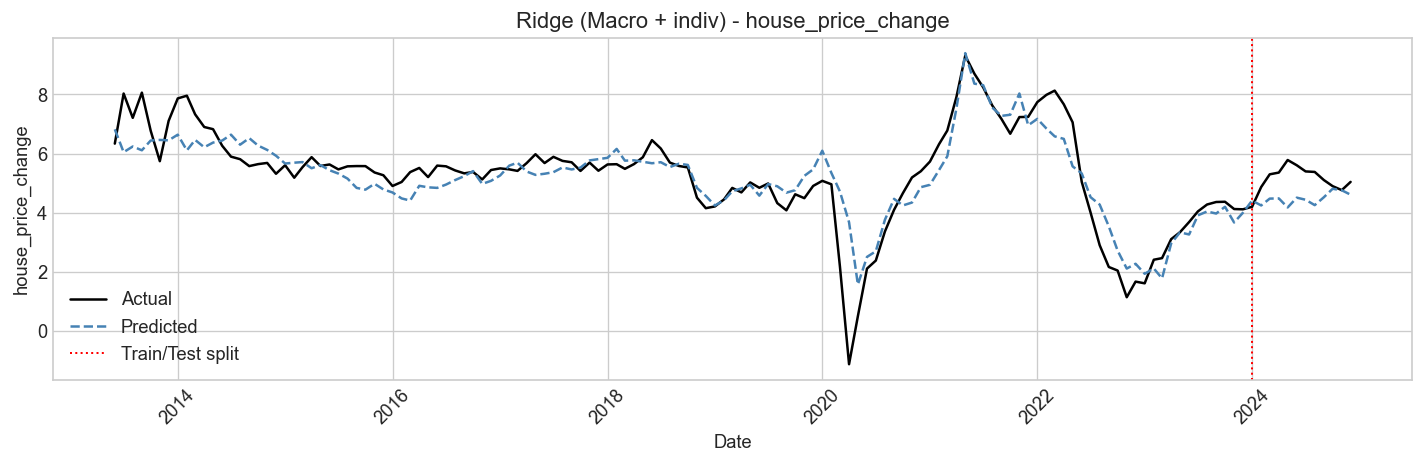

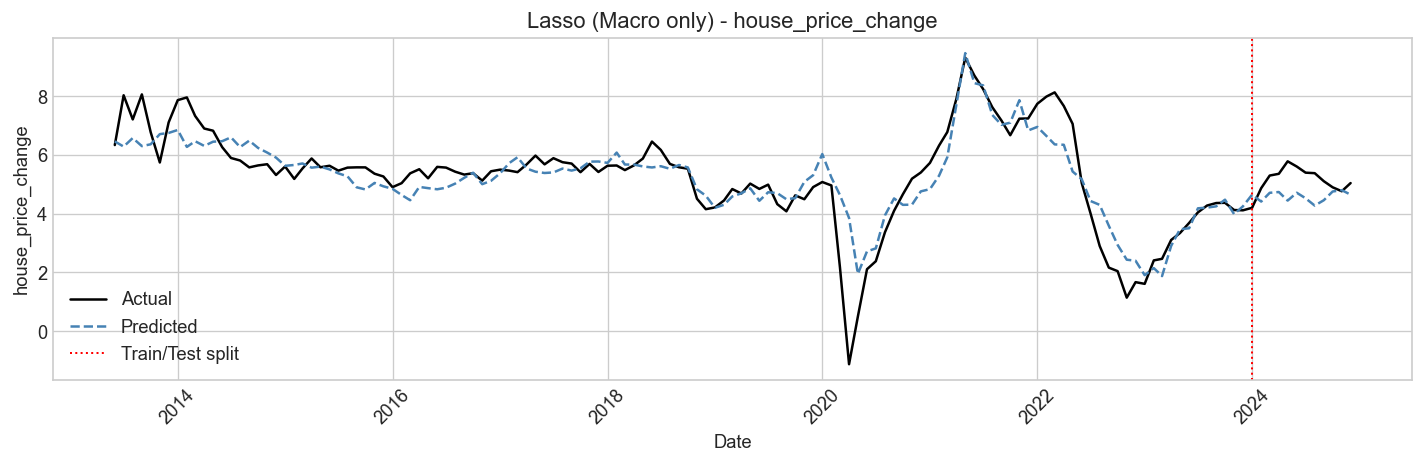

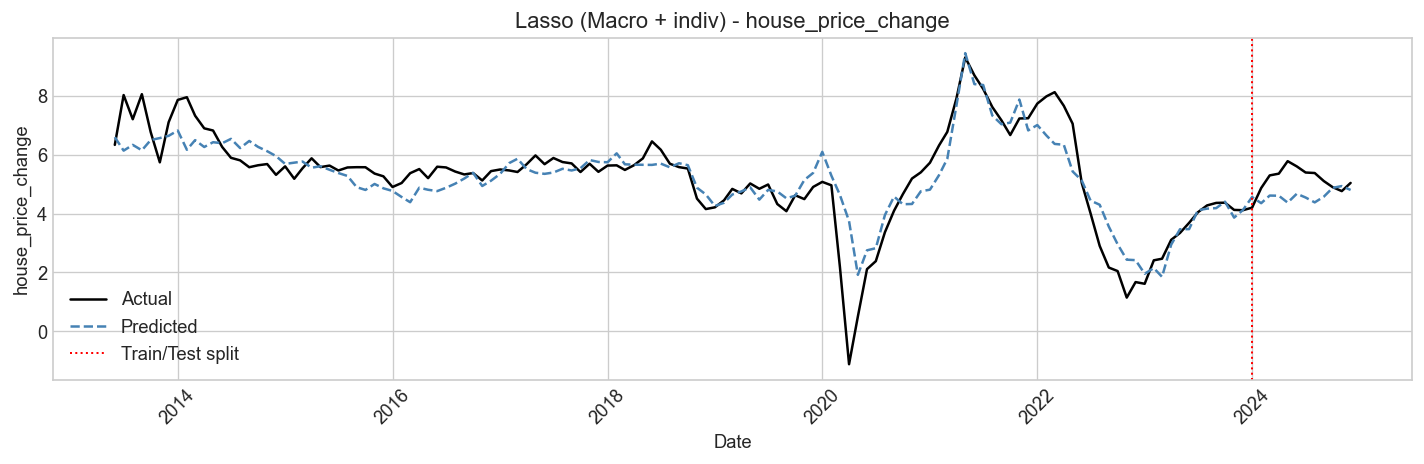

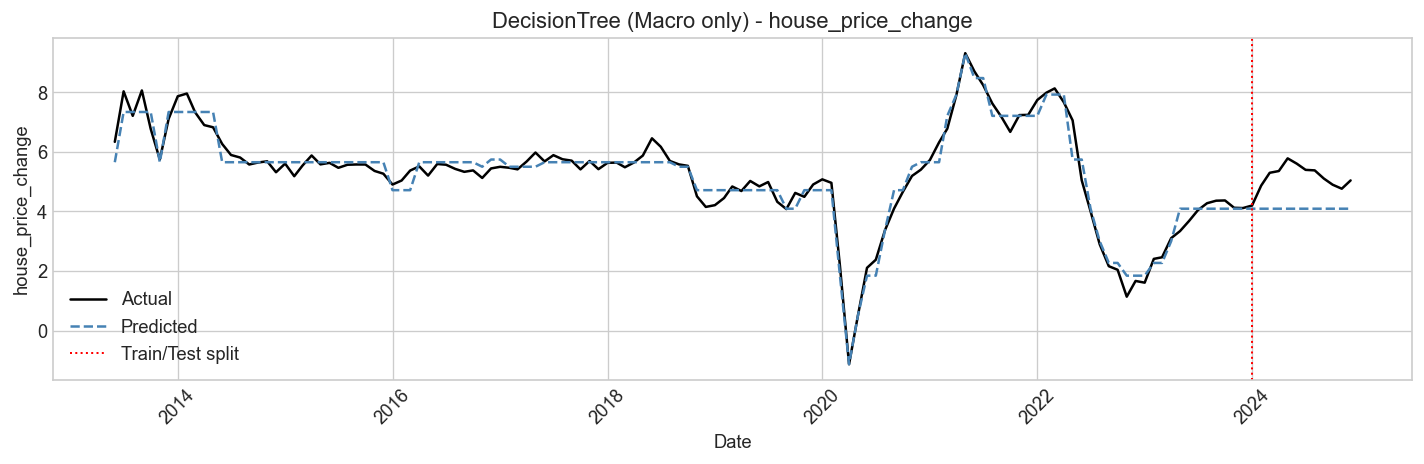

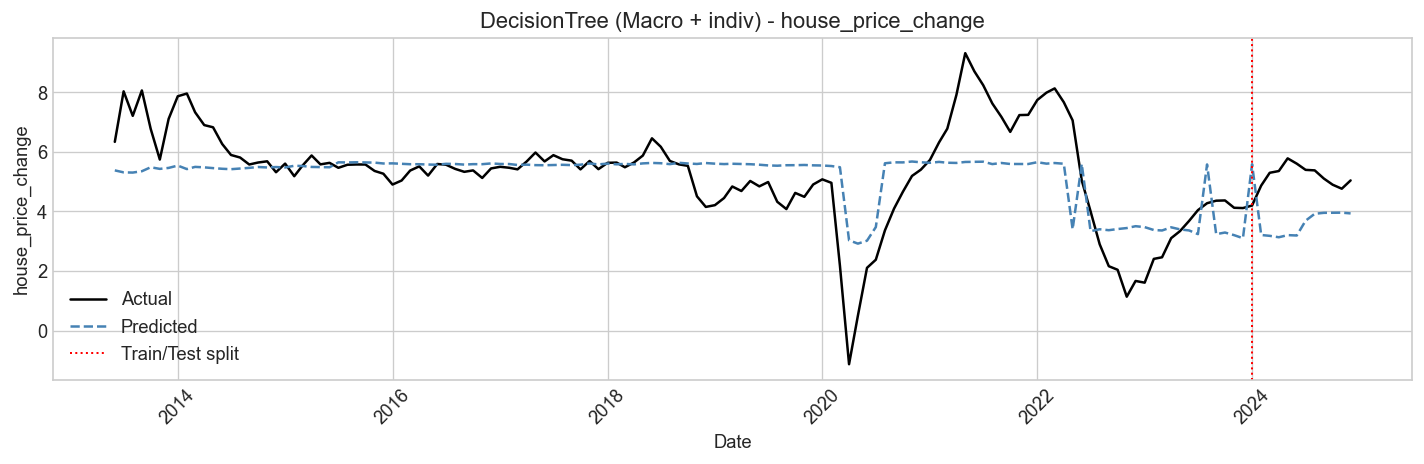

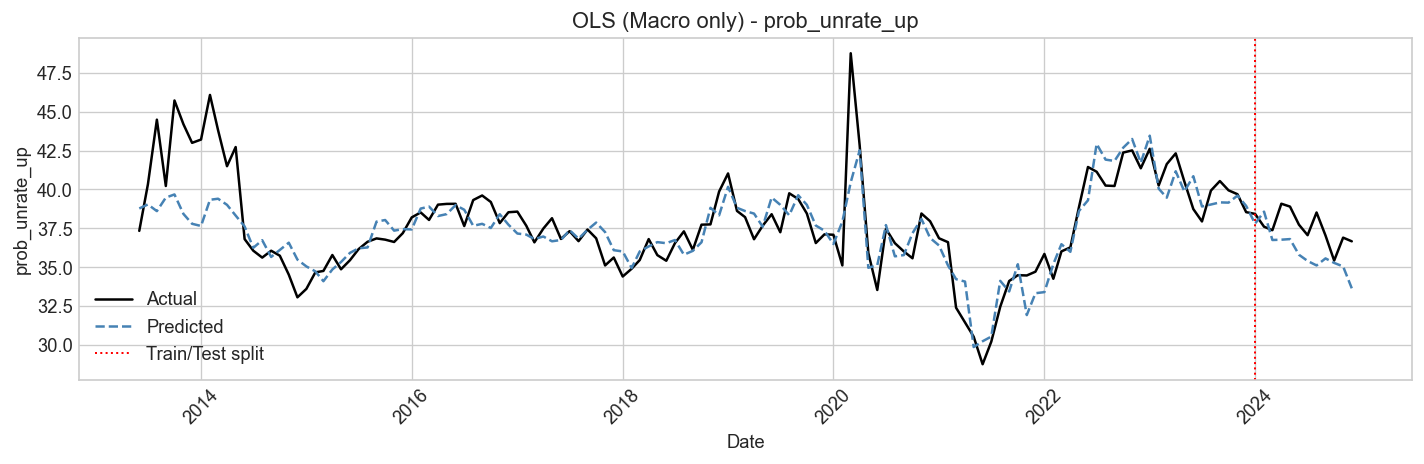

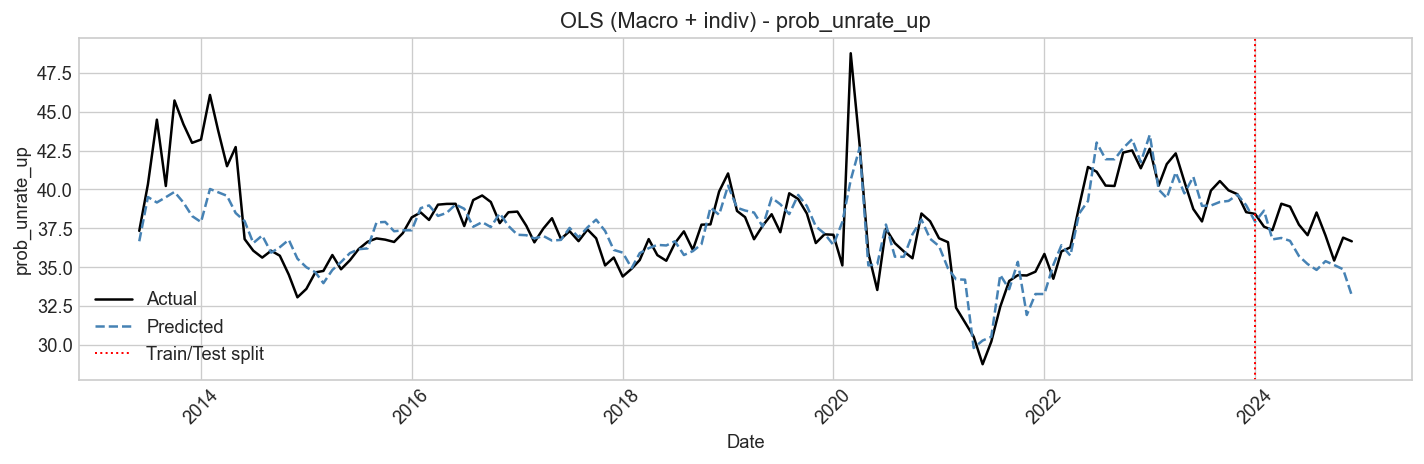

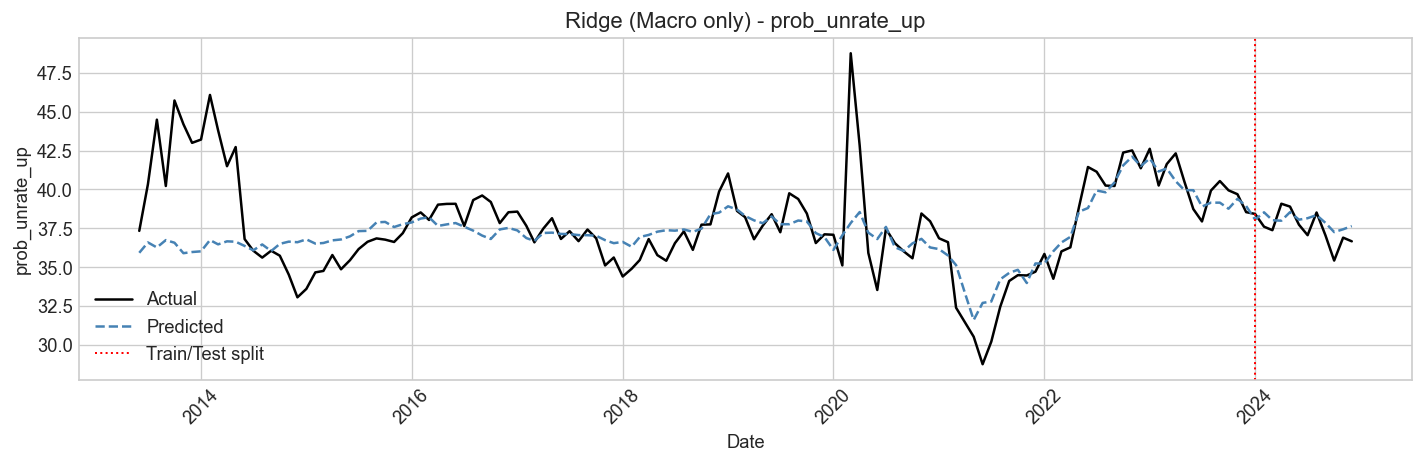

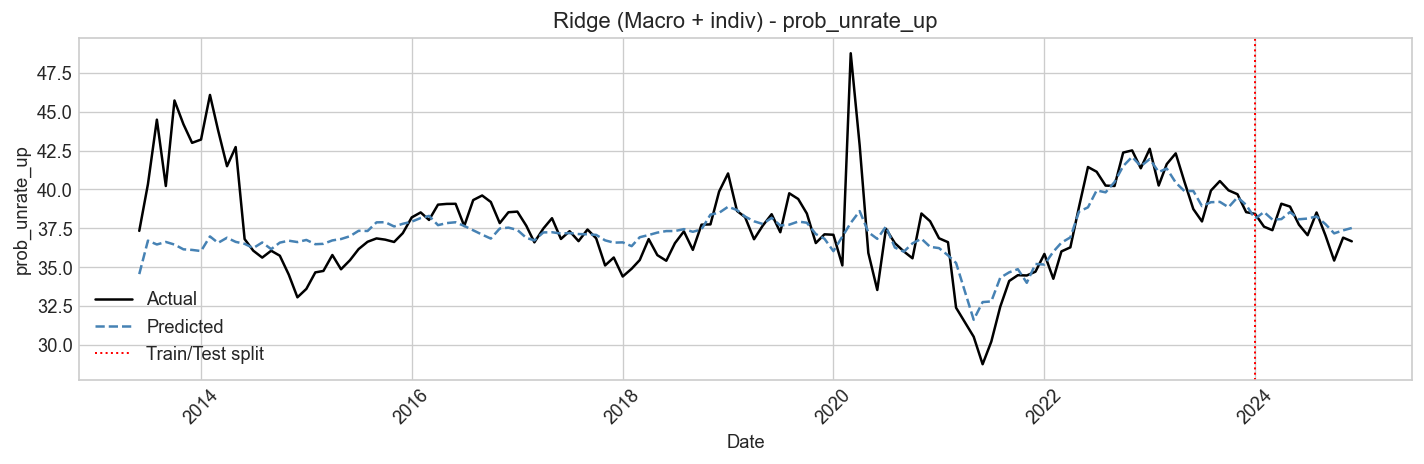

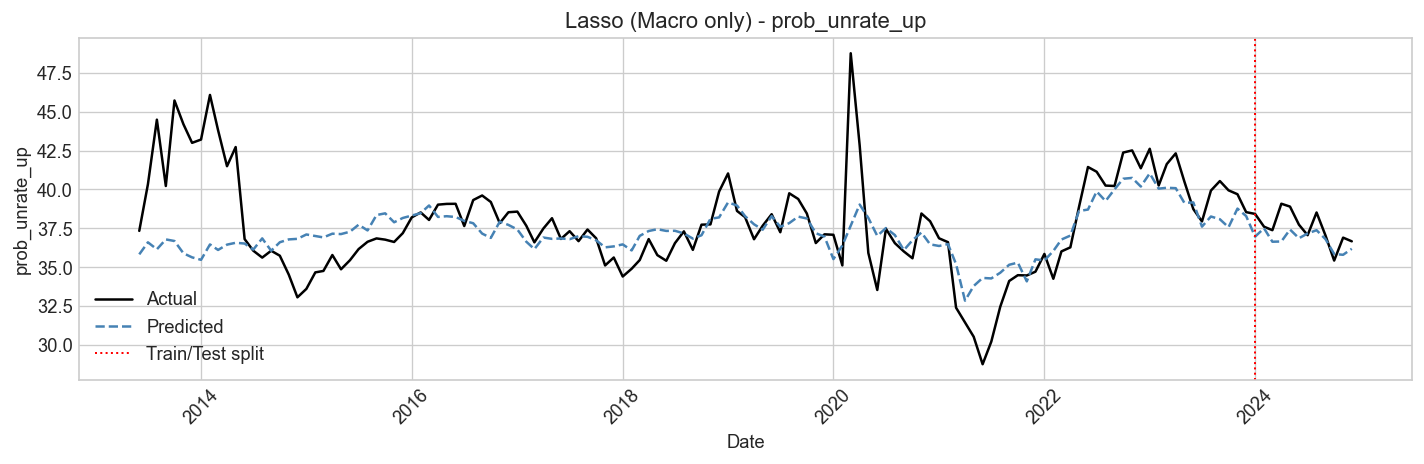

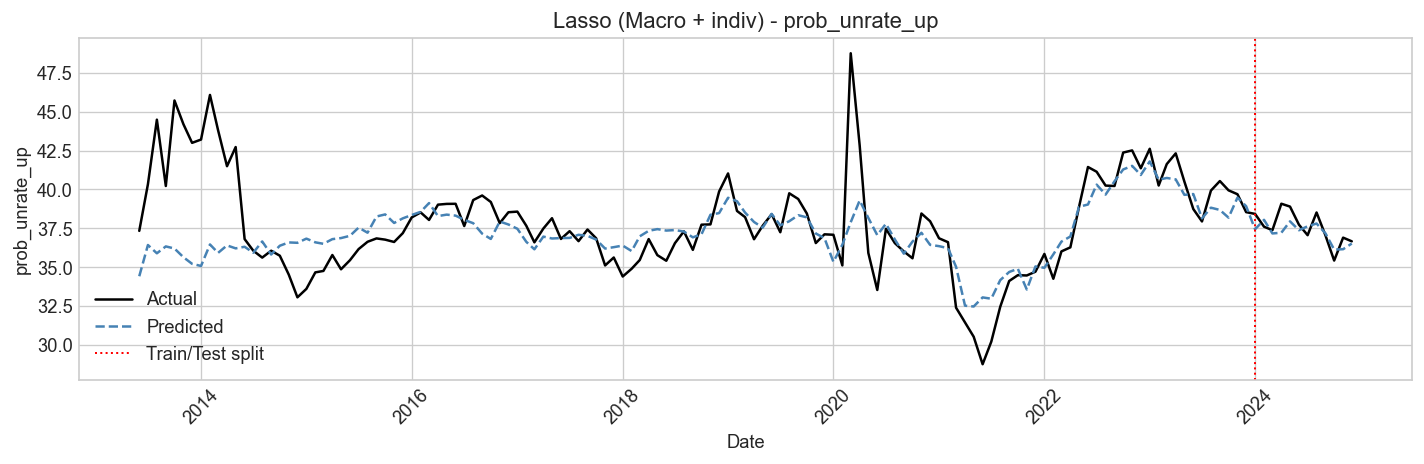

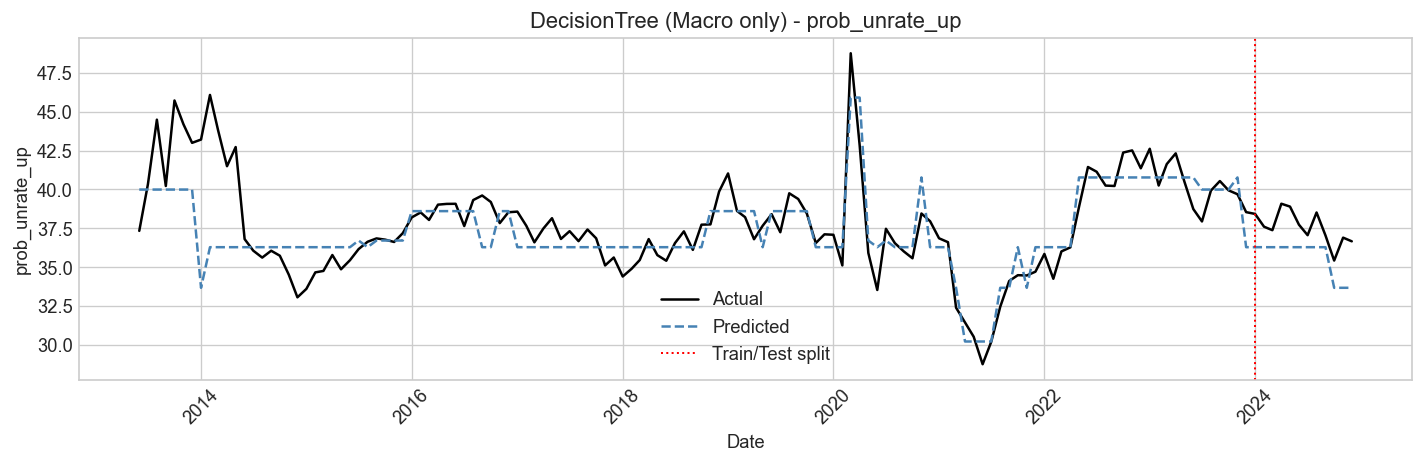

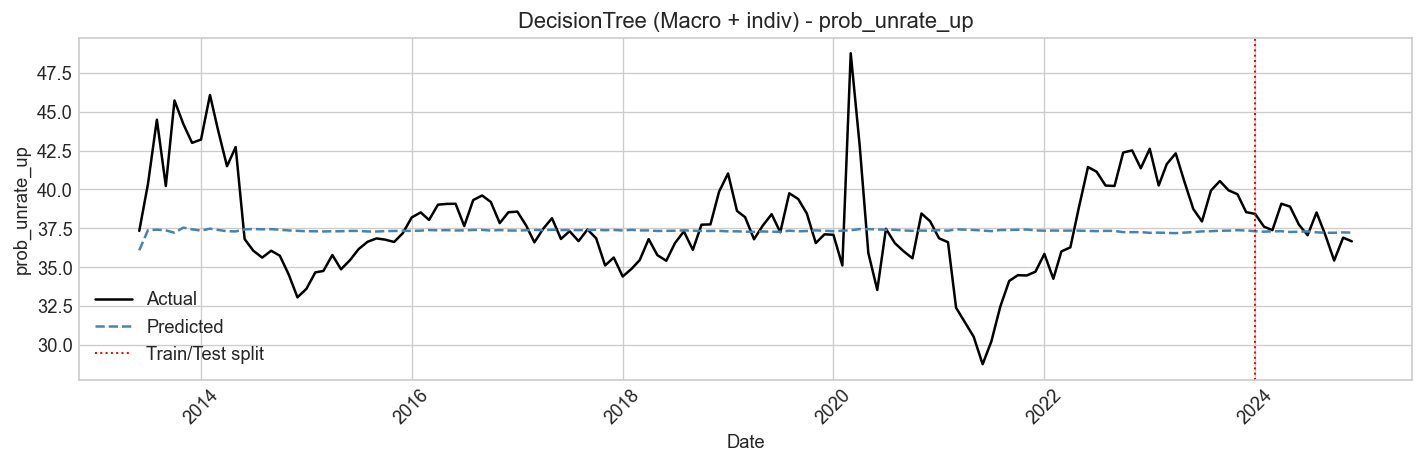

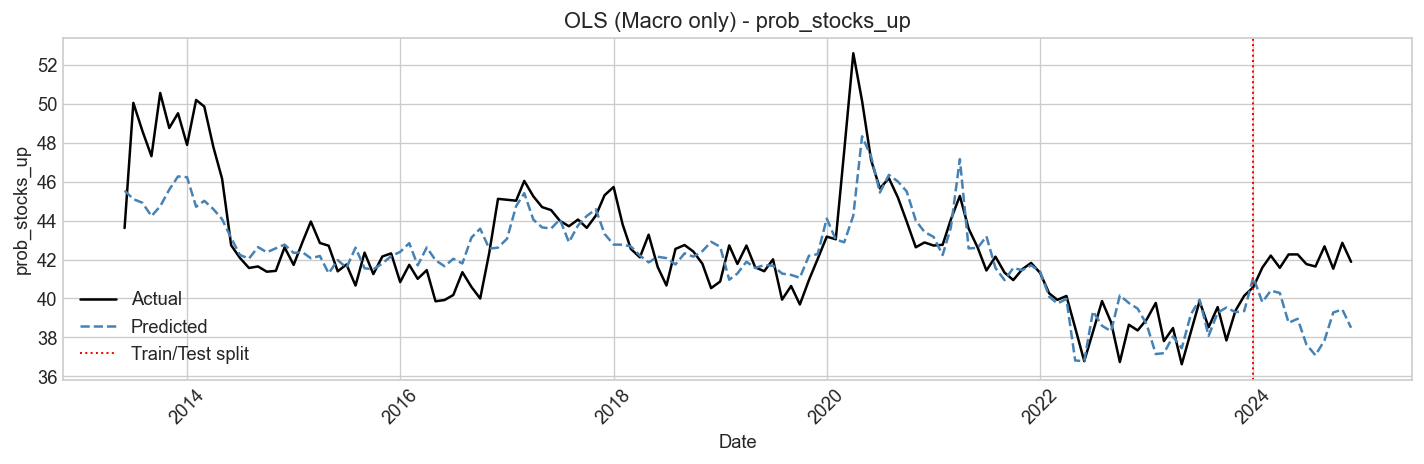

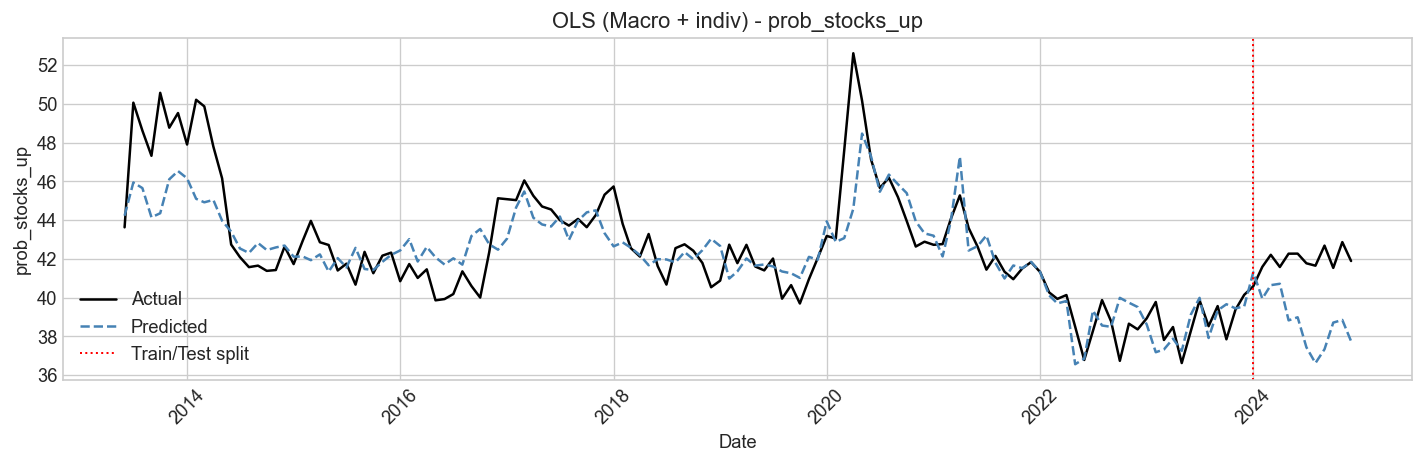

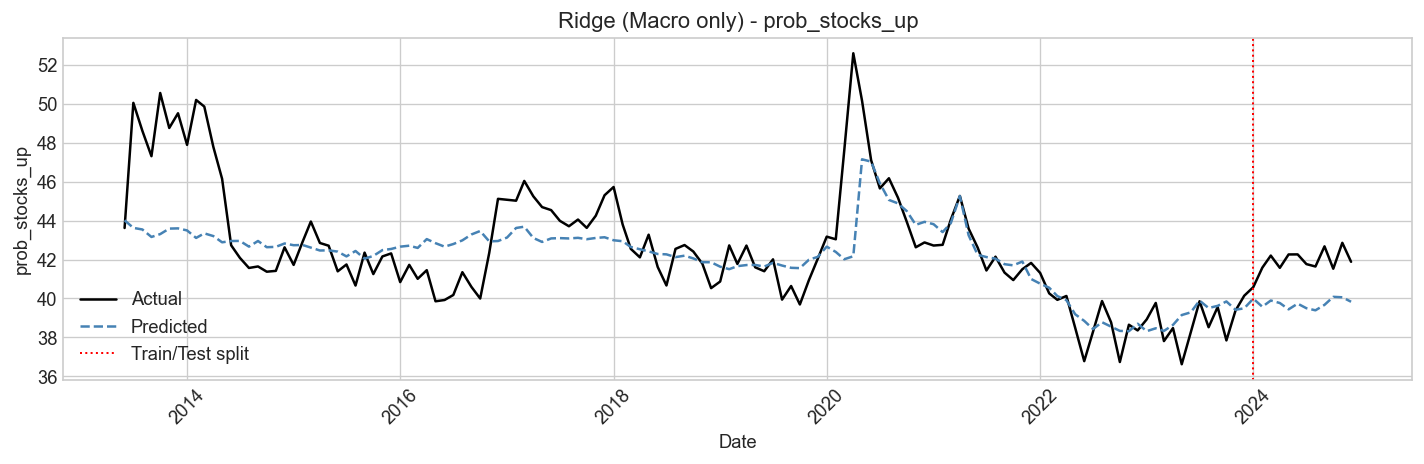

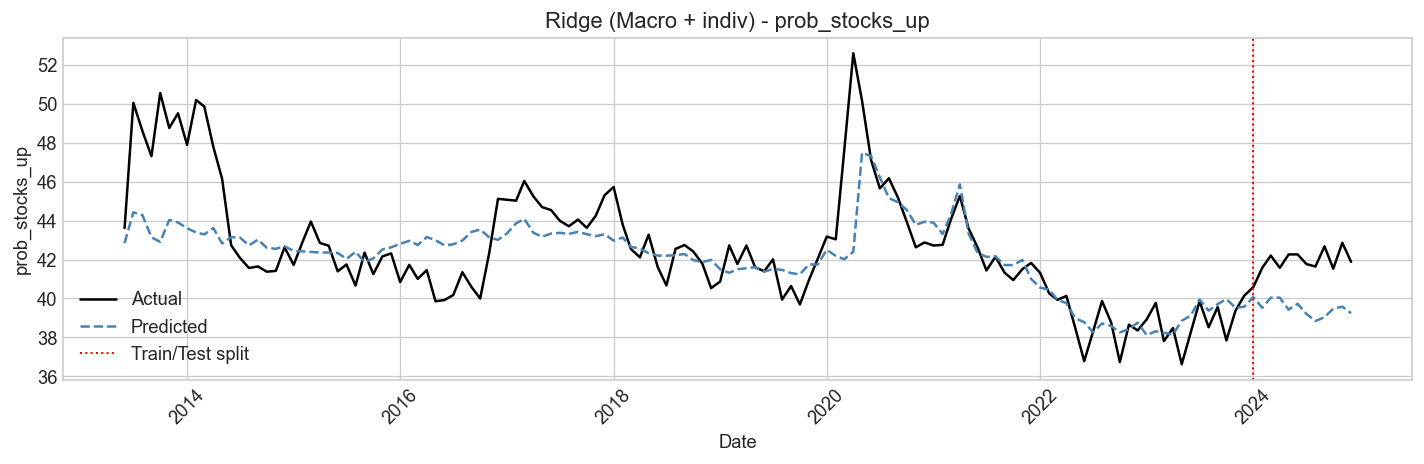

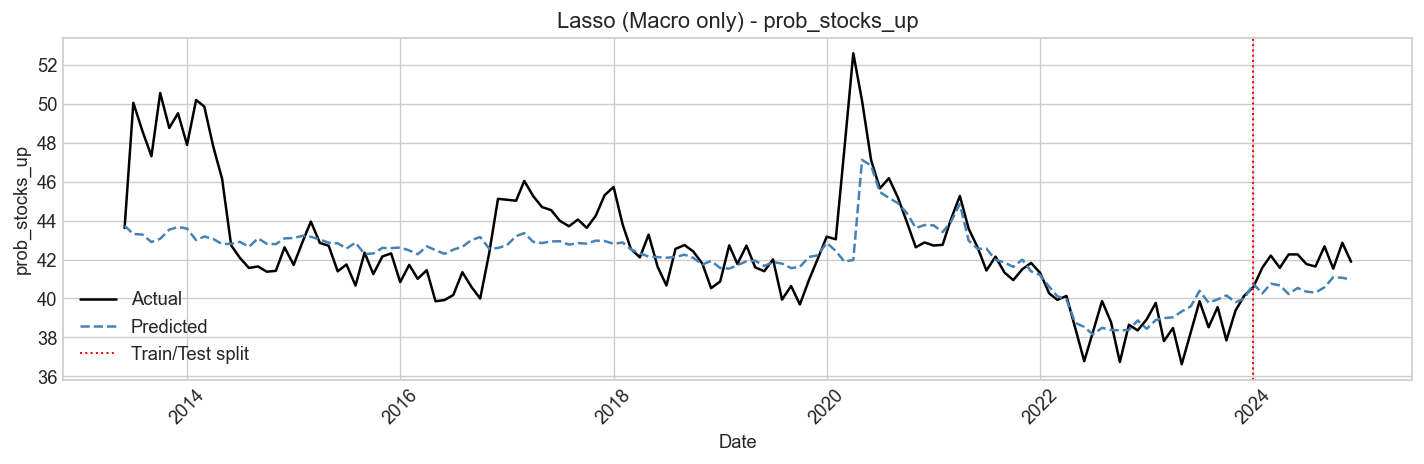

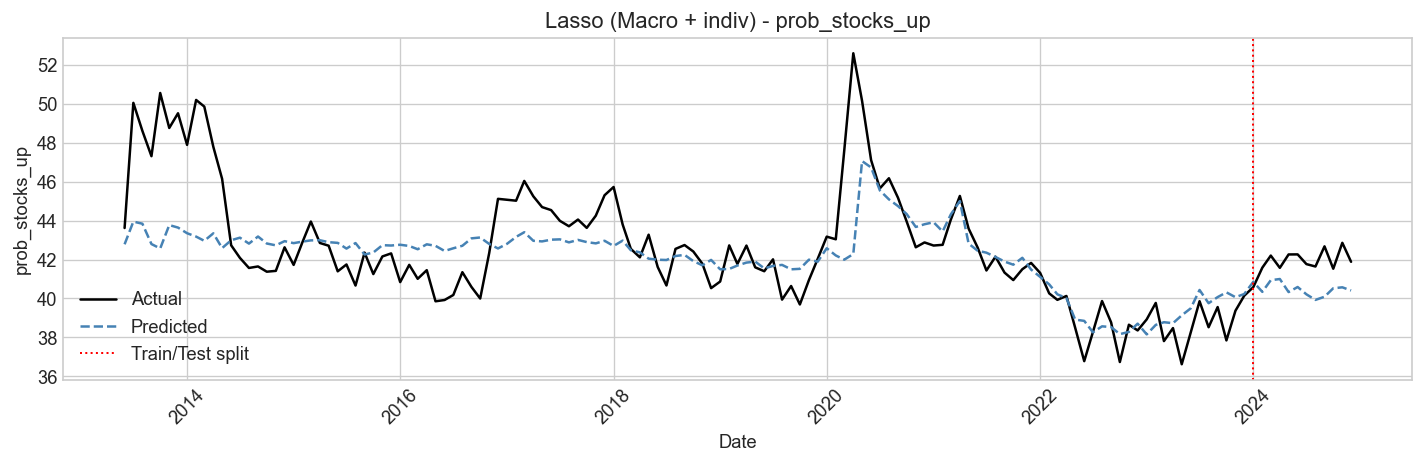

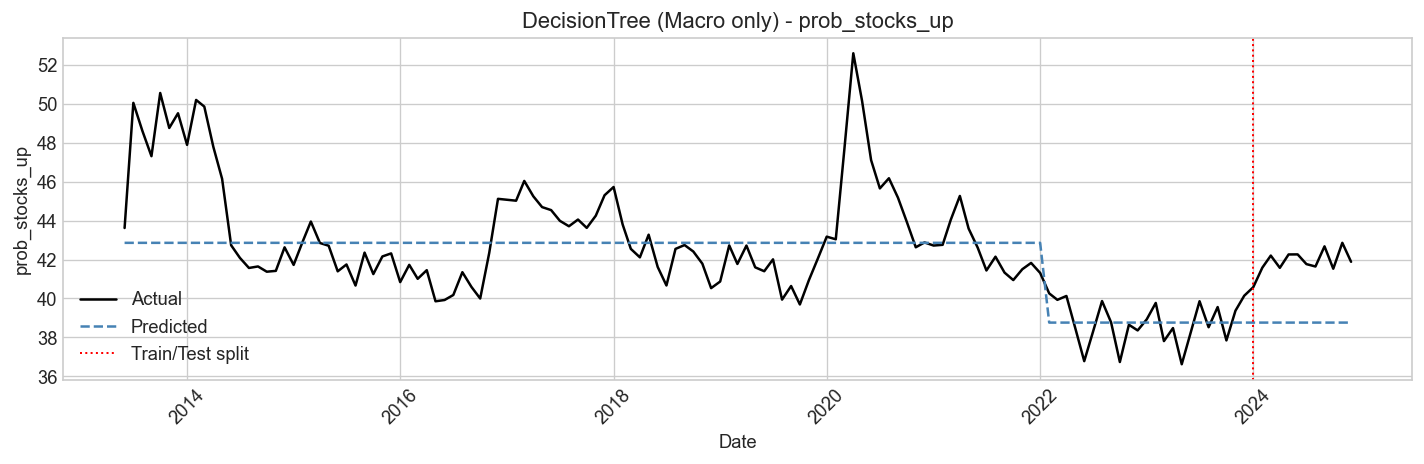

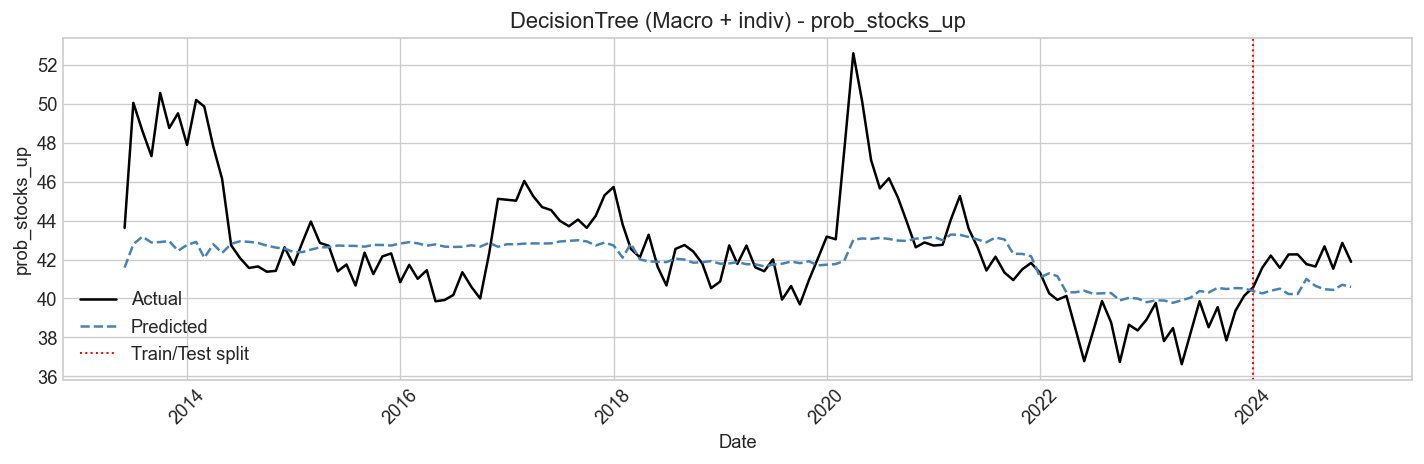

In [46]:
# Build full sample feature matrices for plotting
X_all_macro = sce[MACRO_COLS].values
X_all_full  = np.hstack([
    sce[MACRO_COLS].values,
    sce[INDIV_CONT_COLS].values,
    ohe.transform(sce[INDIV_CAT_COLS])
])

for target in TARGET_VARS:
    for model_name in ["OLS", "Ridge", "Lasso", "DecisionTree"]:
        for label, X_all in [("Macro only", X_all_macro), ("Macro + indiv", X_all_full)]:
            key = f"{model_name} ({label})"
            if key in results[target]:
                model = results[target][key]["model"]
                plot_timeseries_predictions(sce, train, test, model, X_all, target, model_name, label)

The time series plots show that models generally capture broad trends but struggle with sharp shocks. For `infl_1y`, all models track the 2021-2022 surge and decline well. For `house_price_change`, the 2020 drop is consistently underestimated. For `prob_unrate_up`, the COVID-19 spike in 2020 is missed across all models. For `prob_stocks_up`, macro-only models produce near-flat predictions regardless of model type, while adding individual-level variables visibly improves tracking of the actual series.

### 5.11 Test sample metrics summary

In [47]:
print("=== Test Sample Metrics (Part 5) ===\n")

for target in TARGET_VARS:
    print(f"Target: {target}")
    print(f"{'Model':<30} {'RMSE':>8} {'R2':>8}")
    print("-" * 50)
    
    for model_name, res in results[target].items():
        print(f"{model_name:<30} {res['RMSE']:>8.4f} {res['R2']:>8.4f}")
    print()

=== Test Sample Metrics (Part 5) ===

Target: infl_1y
Model                              RMSE       R2
--------------------------------------------------
OLS (Macro only)                 9.2877  -0.0111
OLS (Macro + indiv)              9.0239   0.0455
Ridge (Macro only)               9.2854  -0.0107
Ridge (Macro + indiv)            9.0135   0.0477
Lasso (Macro only)               9.2951  -0.0128
Lasso (Macro + indiv)            9.0235   0.0456
DecisionTree (Macro only)        9.2434  -0.0015
DecisionTree (Macro + indiv)     9.0235   0.0456

Target: house_price_change
Model                              RMSE       R2
--------------------------------------------------
OLS (Macro only)                 8.4617  -0.0027
OLS (Macro + indiv)              8.2615   0.0442
Ridge (Macro only)               8.4908  -0.0096
Ridge (Macro + indiv)            8.2677   0.0427
Lasso (Macro only)               8.4715  -0.0050
Lasso (Macro + indiv)            8.2585   0.0449
DecisionTree (Macro only)       

Including individual-level variables generally leads to a consistent improvement in predictive performance
across models and target variables. For example, for `infl_1y`, adding demographic and
literacy variables reduces the RMSE from around 9.24 to 9.01 and increases R2 from negative
values to around 4-5%. The improvement is most pronounced for `prob_stocks_up`, where Lasso
with individual variables achieves an R2 of around 12.4% on the test sample.

The one exception is the Decision Tree for `house_price_change`, where adding individual variables deteriorates test performance (R2 -1.5 vs -2.9%). This indicates that the tree overfits to the individual-level features for this particular target.

However, the overall predictive performance remains modest, which is consistent with the
expectation that macro/finance variables alone explain little of the individual-level variation
in expectations. The regularised models (Ridge and Lasso) perform similarly to OLS, suggesting
that with the relatively small number of features used here, regularisation does not provide
a large benefit. The Decision Tree performs comparably to the linear models, indicating that
non-linear relationships do not add much predictive power in this setting.

## Part 6 - Predicting Binary Optimism Variables
***

This section repeats the analysis from Part 5 using the three binary optimism variables
as targets. Since these are binary variables, this is a classification task. We use
logistic regression and random forest as required, and evaluate models using standard
classification metrics.

### 6.1 Feature sets and train/test split

We use the same train/test split and feature sets as in Part 5.

In [48]:
# Binary target variables
BINARY_TARGETS = ["optimist_unrate", "optimist_stocks", "optimist_house_price"]

print("Class balance in training set:")

for target in BINARY_TARGETS:
    mean = train[target].mean()
    print(f"  {target}: {mean:.1%} positive")

Class balance in training set:
  optimist_unrate: 60.3% positive
  optimist_stocks: 30.7% positive
  optimist_house_price: 83.5% positive


### 6.2 Helper functions for classification

In [49]:
def evaluate_classification(model, X_test, y_test):

    """Compute classification metrics on the test sample."""

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    metrics = {
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall"   : recall_score(y_test, y_pred, zero_division=0),
        "F1"       : f1_score(y_test, y_pred, zero_division=0),
        "AUC"      : roc_auc_score(y_test, y_proba) if y_proba is not None else None,
    }
    
    return metrics

In [50]:
def evaluate_classification_train(model, X_train, y_train):

    """Compute classification metrics on the training sample."""

    y_pred  = model.predict(X_train)
    y_proba = model.predict_proba(X_train)[:, 1] if hasattr(model, "predict_proba") else None
    metrics = {
        "Accuracy" : accuracy_score(y_train, y_pred),
        "Precision": precision_score(y_train, y_pred, zero_division=0),
        "Recall"   : recall_score(y_train, y_pred, zero_division=0),
        "F1"       : f1_score(y_train, y_pred, zero_division=0),
        "AUC"      : roc_auc_score(y_train, y_proba) if y_proba is not None else None,
    }
    
    return metrics

In [51]:
def plot_optimist_predictions(sce, model, X_all, target, model_name, feature_label):
    
    """Plot monthly actual vs predicted fraction of optimists with train/test split marker."""

    df_plot = sce.copy()
    df_plot["predicted"] = model.predict(X_all)

    monthly_actual    = sce.groupby(sce["date"].dt.to_period("M"))[target].mean()
    monthly_predicted = df_plot.groupby(df_plot["date"].dt.to_period("M"))["predicted"].mean()

    monthly_actual.index    = monthly_actual.index.to_timestamp()
    monthly_predicted.index = monthly_predicted.index.to_timestamp()

    split_date = pd.Timestamp("2024-01-01")

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(monthly_actual.index, monthly_actual.values * 100,
            color="black", linewidth=1.5, label="Actual")
    ax.plot(monthly_predicted.index, monthly_predicted.values * 100,
            color="steelblue", linewidth=1.5, linestyle="--", label="Predicted")
    
    ax.axvline(split_date, color="red", linestyle=":", linewidth=1.2, label="Train/Test split")
    ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Date")
    ax.set_ylabel("Fraction of optimists (%)")
    ax.set_title(f"{model_name} ({feature_label}) - {target}")
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

### 6.3 Logistic Regression

Logistic regression is the standard model for binary classification. It requires feature
scaling and has one hyperparameter: the regularisation strength C (inverse of alpha).
A higher C means less regularisation. We use 5-fold cross-validation with
`LogisticRegressionCV` to select the optimal C from a log-spaced grid between 0.001 and 1000.
The optimal C and accuracy metrics on both training and test samples are reported below.

In [52]:
# Fit logistic regression with cross-validated C for each binary target
results_clf = {}
Cs = np.logspace(-3, 3, 20)

for target in BINARY_TARGETS:
    results_clf[target] = {}
    y_train_b = train[target].values
    y_test_b  = test[target].values

    for label, X_tr, X_te in [
        ("Macro only",    X_train_macro, X_test_macro),
        ("Macro + indiv", X_train_full,  X_test_full),
    ]:
        model = make_pipeline(
            StandardScaler(),
            LogisticRegressionCV(Cs=Cs, cv=5, max_iter=1000, n_jobs=-1, penalty="l2", solver="lbfgs") #Added penalty and solver for clean output
        )

        model.fit(X_tr, y_train_b)
        best_C = model.named_steps["logisticregressioncv"].C_[0]
        metrics = evaluate_classification(model, X_te, y_test_b)
        train_metrics = evaluate_classification_train(model, X_tr, y_train_b)
        results_clf[target][f"LogReg ({label})"] = {
            "metrics": metrics, "train_metrics": train_metrics, "model": model
        }
        
        print(f"{target} | LogReg | {label} -> C = {best_C:.4f}, "
              f"Acc = {metrics['Accuracy']:.4f}, F1 = {metrics['F1']:.4f}, AUC = {metrics['AUC']:.4f}")

optimist_unrate | LogReg | Macro only -> C = 0.0010, Acc = 0.5861, F1 = 0.7390, AUC = 0.5163
optimist_unrate | LogReg | Macro + indiv -> C = 0.0010, Acc = 0.5871, F1 = 0.7392, AUC = 0.6210
optimist_stocks | LogReg | Macro only -> C = 0.0010, Acc = 0.6734, F1 = 0.0000, AUC = 0.5126
optimist_stocks | LogReg | Macro + indiv -> C = 0.0010, Acc = 0.6745, F1 = 0.0151, AUC = 0.6927
optimist_house_price | LogReg | Macro only -> C = 0.0010, Acc = 0.7881, F1 = 0.8815, AUC = 0.4932
optimist_house_price | LogReg | Macro + indiv -> C = 0.0010, Acc = 0.7881, F1 = 0.8815, AUC = 0.5206


We tested a wider grid for the regularization parameter $C$, and found that values around the lower bound were consistently selected, suggesting strong regularization. A value of $C = 0.001$ indicates near maximum regularization, placing little weight on the features, leading the model to mainly predict the majority class.

### 6.4 Random Forest

Random forest is an ensemble method that fits many decision trees and averages their
predictions. It does not require feature scaling. The key hyperparameter is `max_depth`
which controls the complexity of each tree. We use 5-fold cross-validation with AUC
as the scoring metric to select the optimal depth from {2, 3, 5, 7, 10}.
The optimal depth and accuracy metrics on both training and test samples are reported below.

In [53]:
# Fit random forest with cross-validated max_depth for each binary target
depths = [2, 3, 5, 7, 10]

for target in BINARY_TARGETS:
    y_train_b = train[target].values
    y_test_b  = test[target].values

    for label, X_tr, X_te in [
        ("Macro only",    X_train_macro, X_test_macro),
        ("Macro + indiv", X_train_full,  X_test_full),
    ]:
        
        val_scores = []
        for d in depths:
            scores = cross_validate(
                RandomForestClassifier(max_depth=d, n_estimators=100,
                                       random_state=42, n_jobs=-1),
                X_tr, y_train_b,
                scoring="roc_auc",
                cv=5
            )

            val_scores.append(scores["test_score"].mean())

        best_depth = depths[np.argmax(val_scores)]
        model = RandomForestClassifier(max_depth=best_depth, n_estimators=100,
                                       random_state=42, n_jobs=-1)
        model.fit(X_tr, y_train_b)
        metrics = evaluate_classification(model, X_te, y_test_b)
        train_metrics = evaluate_classification_train(model, X_tr, y_train_b)
        results_clf[target][f"RandomForest ({label})"] = {
            "metrics": metrics, "train_metrics": train_metrics, "model": model
        }
        
        print(f"{target} | RF | {label} -> depth = {best_depth}, "
              f"Acc = {metrics['Accuracy']:.4f}, F1 = {metrics['F1']:.4f}, AUC = {metrics['AUC']:.4f}")

optimist_unrate | RF | Macro only -> depth = 10, Acc = 0.5861, F1 = 0.7390, AUC = 0.5211
optimist_unrate | RF | Macro + indiv -> depth = 10, Acc = 0.6174, F1 = 0.7268, AUC = 0.6368
optimist_stocks | RF | Macro only -> depth = 5, Acc = 0.6734, F1 = 0.0000, AUC = 0.5024
optimist_stocks | RF | Macro + indiv -> depth = 2, Acc = 0.6734, F1 = 0.0000, AUC = 0.6840
optimist_house_price | RF | Macro only -> depth = 2, Acc = 0.7881, F1 = 0.8815, AUC = 0.4926
optimist_house_price | RF | Macro + indiv -> depth = 10, Acc = 0.7880, F1 = 0.8814, AUC = 0.5538


For `optimist_stocks`, several models predict no positive cases, resulting in a F1 score of 0. This is due to predicted probabilities consistently lying below the 0.5 threshold, leading the model to classify all observations as the majority class. While AUC may still be above 0.5, it reflects ranking performance rather than classification.

### 6.5 Time series plots - Fraction of optimists

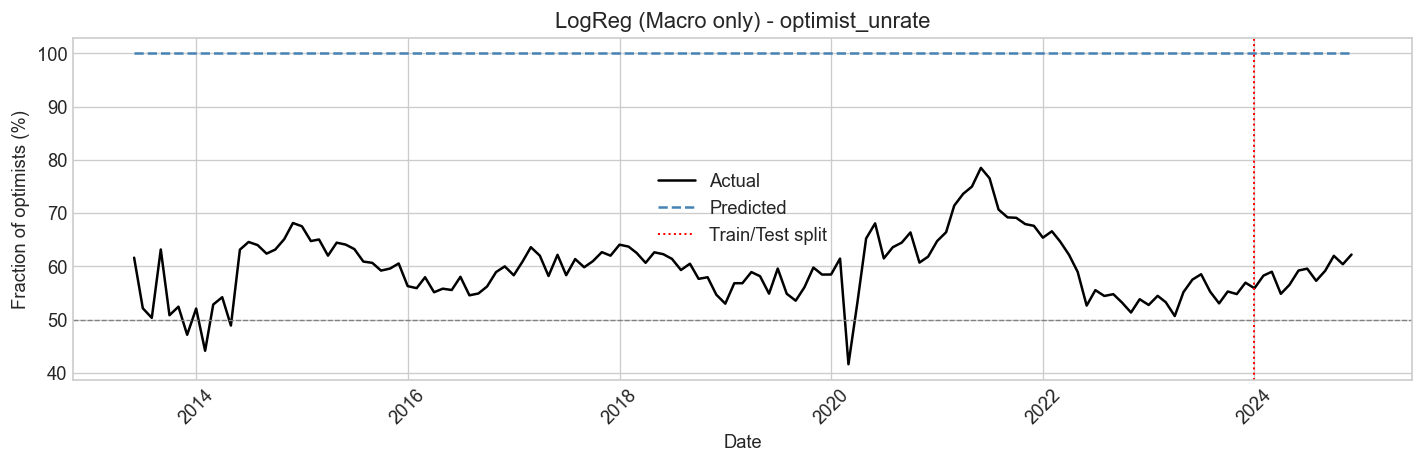

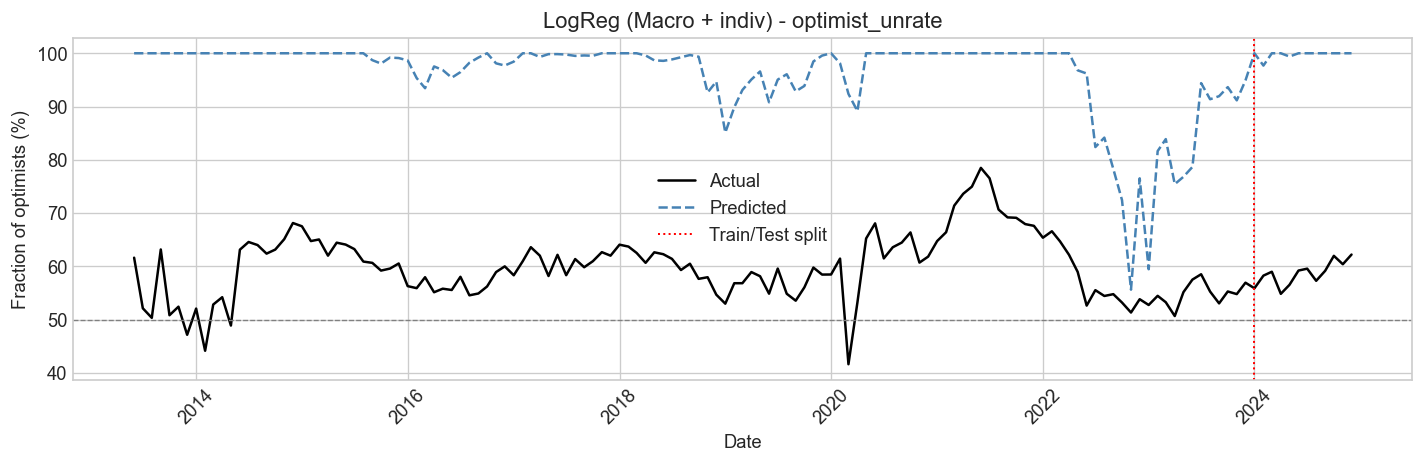

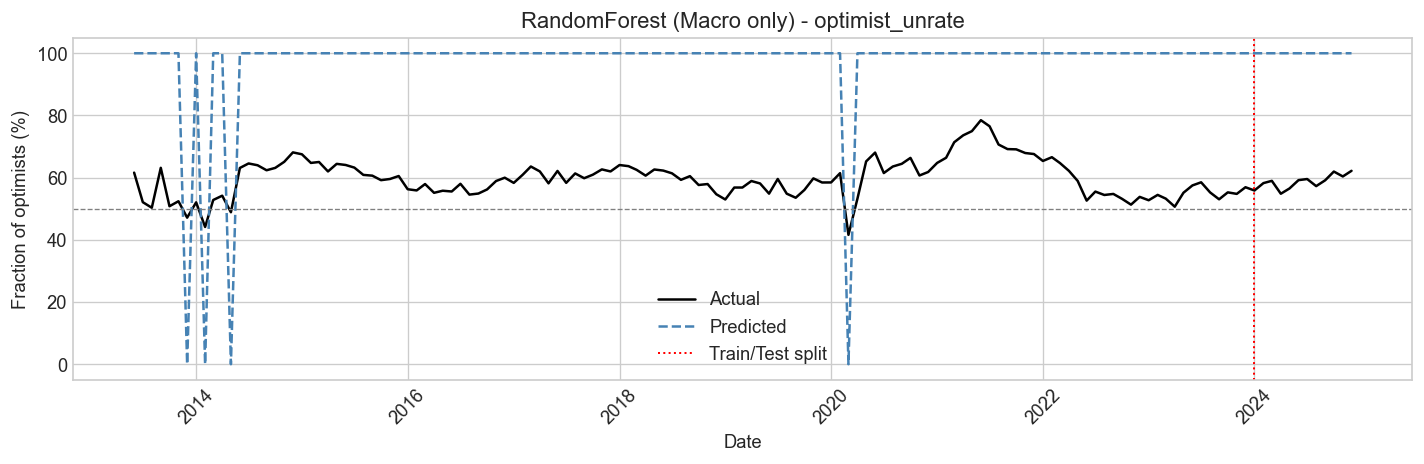

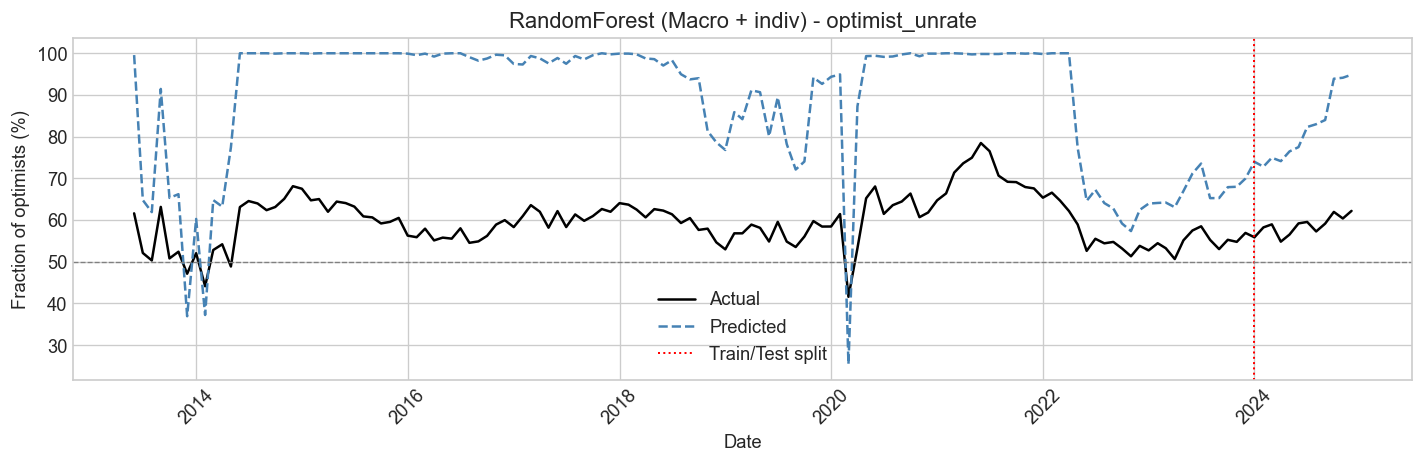

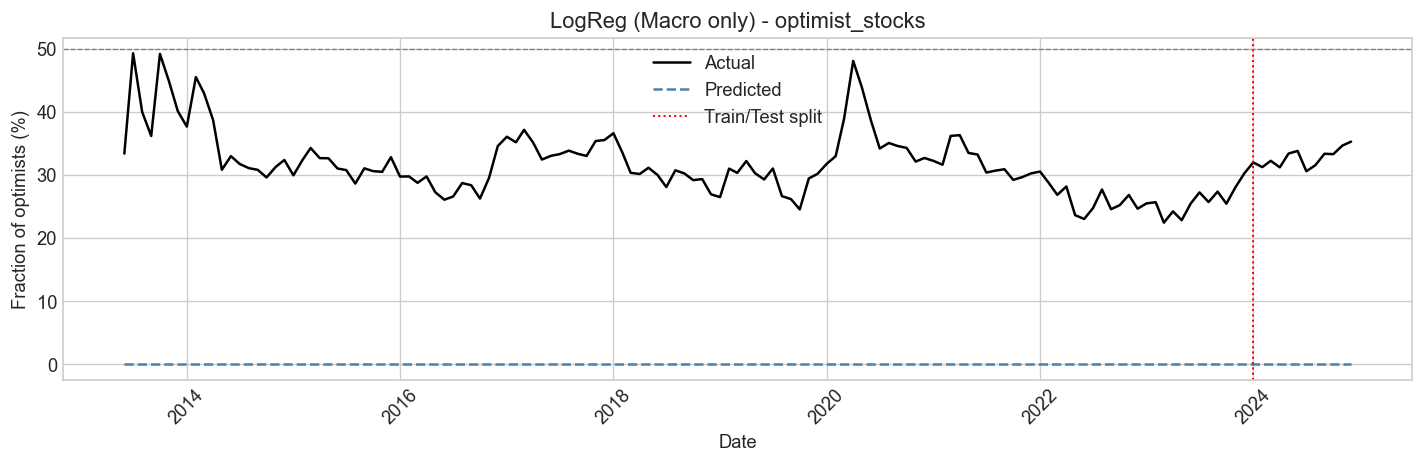

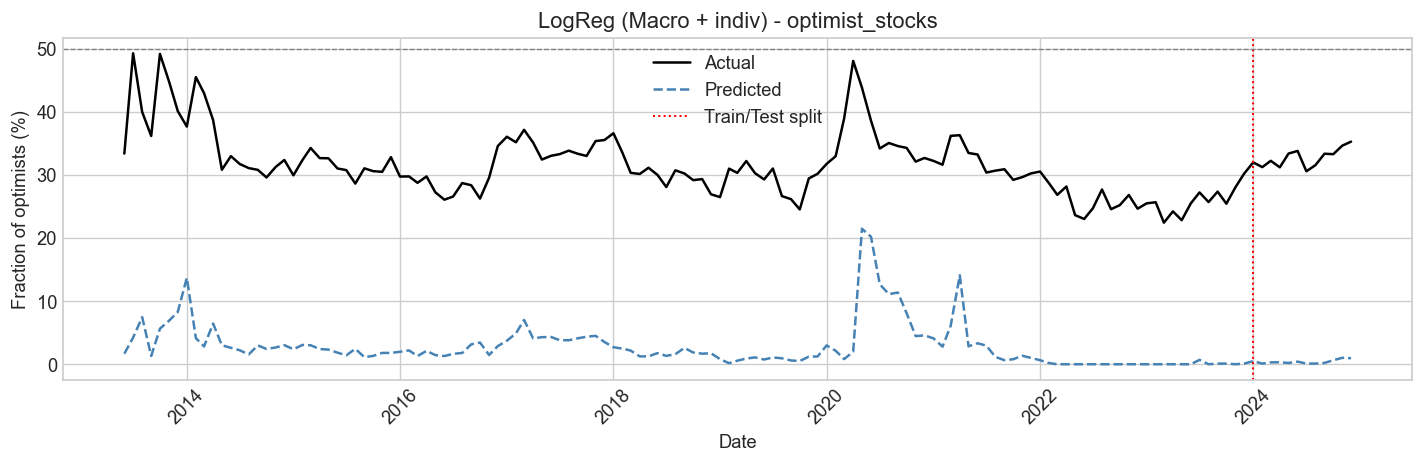

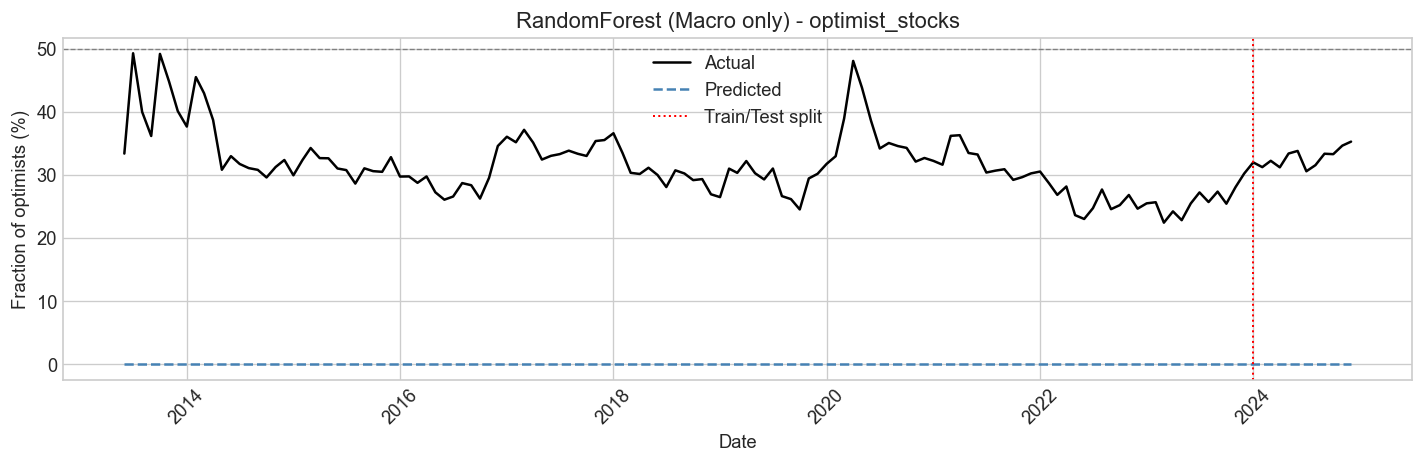

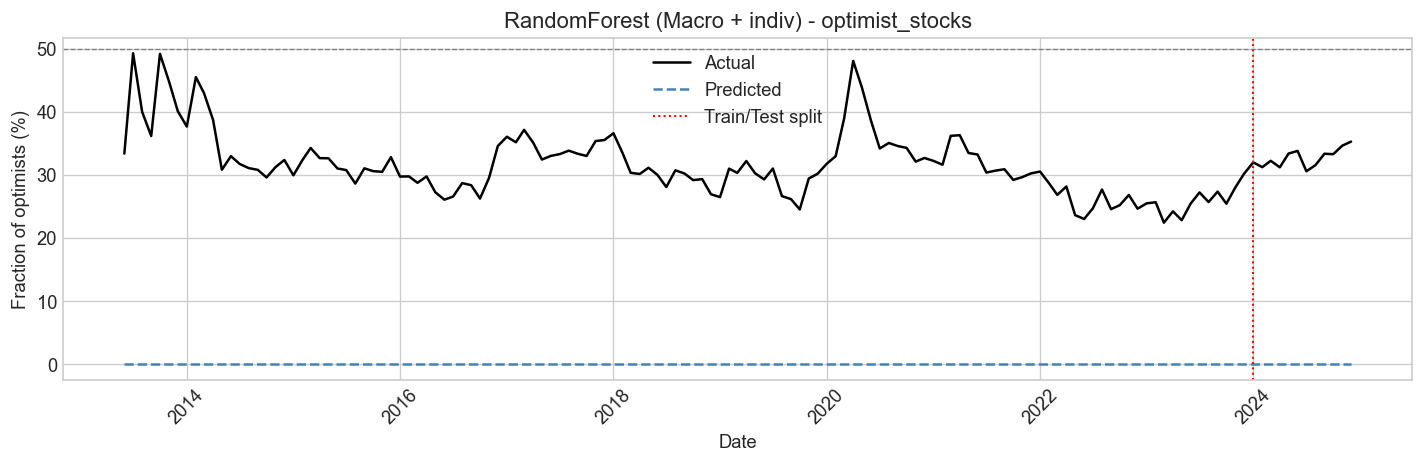

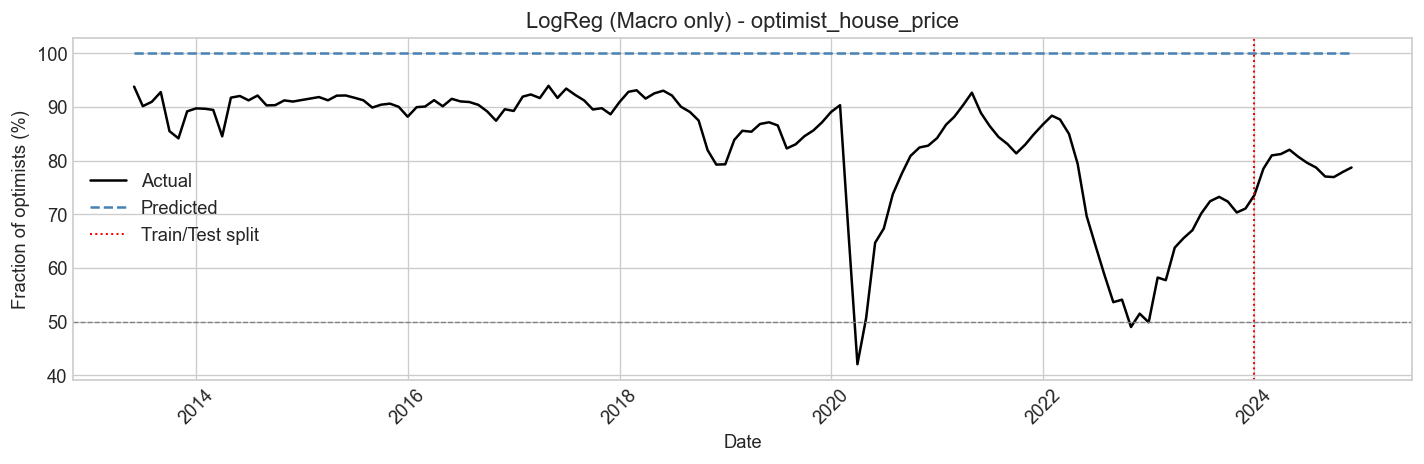

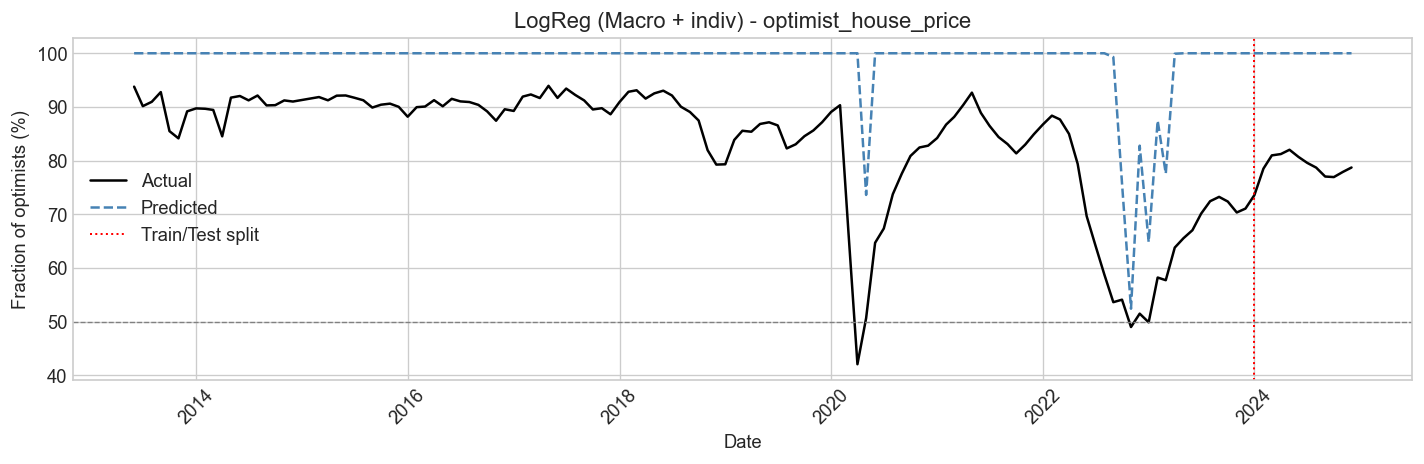

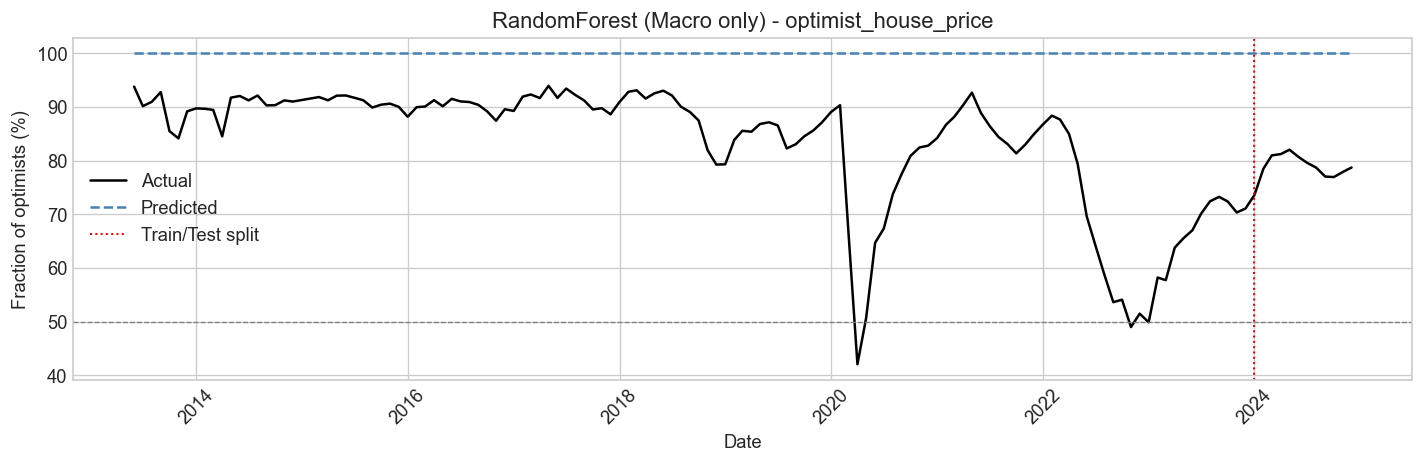

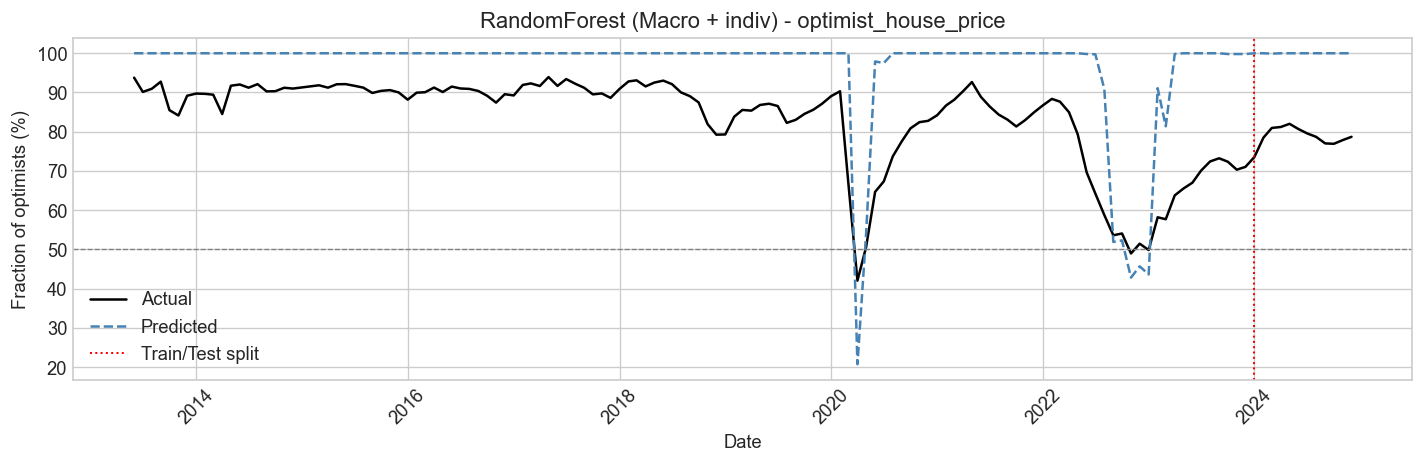

In [54]:
for target in BINARY_TARGETS:
    for model_name in ["LogReg", "RandomForest"]:
        for label, X_all in [("Macro only", X_all_macro), ("Macro + indiv", X_all_full)]:
            key = f"{model_name} ({label})"
            if key in results_clf[target]:
                model = results_clf[target][key]["model"]
                plot_optimist_predictions(sce, model, X_all, target, model_name, label)

The classification plots show that macro-only models generally predict near-constant values, reflecting the limited time variation in macro features. Adding individual-level variables improves predictions for `optimist_unrate` and `optimist_stocks`, though turning points remain difficult to capture. For `optimist_house_price`, all models struggle with the sharp 2020 drop, and macro-only models predict the majority class (optimist) for every respondent.

### 6.6 Test sample metrics summary

In [55]:
print("=== Classification Metrics (Part 6) ===\n")

for target in BINARY_TARGETS:
    print(f"Target: {target}")
    print(f"\n  Training sample:")
    print(f"  {'Model':<35} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>6}")
    print("  " + "-" * 65)

    for model_name, res in results_clf[target].items():
        m = res["train_metrics"]
        print(f"  {model_name:<35} {m['Accuracy']:>6.4f} {m['Precision']:>6.4f} "
              f"{m['Recall']:>6.4f} {m['F1']:>6.4f} {m['AUC']:>6.4f}")

    print(f"\n  Test sample:")
    print(f"  {'Model':<35} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>6}")
    print("  " + "-" * 65)
    
    for model_name, res in results_clf[target].items():
        m = res["metrics"]
        print(f"  {model_name:<35} {m['Accuracy']:>6.4f} {m['Precision']:>6.4f} "
              f"{m['Recall']:>6.4f} {m['F1']:>6.4f} {m['AUC']:>6.4f}")
    print()

=== Classification Metrics (Part 6) ===

Target: optimist_unrate

  Training sample:
  Model                                  Acc   Prec    Rec     F1    AUC
  -----------------------------------------------------------------
  LogReg (Macro only)                 0.6033 0.6033 1.0000 0.7526 0.5563
  LogReg (Macro + indiv)              0.6112 0.6118 0.9728 0.7512 0.5786
  RandomForest (Macro only)           0.6047 0.6051 0.9924 0.7518 0.5649
  RandomForest (Macro + indiv)        0.6333 0.6303 0.9488 0.7574 0.6700

  Test sample:
  Model                                  Acc   Prec    Rec     F1    AUC
  -----------------------------------------------------------------
  LogReg (Macro only)                 0.5861 0.5861 1.0000 0.7390 0.5163
  LogReg (Macro + indiv)              0.5871 0.5868 0.9987 0.7392 0.6210
  RandomForest (Macro only)           0.5861 0.5861 1.0000 0.7390 0.5211
  RandomForest (Macro + indiv)        0.6174 0.6249 0.8685 0.7268 0.6368

Target: optimist_stocks

  Train

The classification results reveal important patterns. For `optimist_house_price`, most models
achieve high accuracy (~79%) by predicting the majority class (optimist) for all
observations, since 83% of respondents are optimistic about house prices. This naive strategy
inflates both accuracy and F1 scores, as predicting the majority class correctly classifies most observations. In contrast, the AUC score is more informative in this regard, as it accounts for ranking performance rather than classification at a fixed threshold.

When using only macro/finance variables, models tend to predict the same class for all
observations. This is expected: macro variables vary only over time and not across individuals,
so models trained on them will produce nearly identical predictions for all respondents in a
given month. Adding individual-level variables breaks this pattern and substantially improves
the AUC, particularly for `optimist_stocks` where AUC increases from 0.50 to 0.69.

For `optimist_unrate`, adding individual variables improves both accuracy and AUC, with Random
Forest achieving the best AUC of 0.63. Overall, individual-level variables provide meaningful
improvements in classification performance, particularly for stock market optimism.

## Part 7 - Conclusion
***

This section summarises the results from Parts 5 and 6, comparing model performance
across feature sets and identifying which models and feature sets performed best.

In [56]:
# Build summary table for Part 5
rows = []
for target in TARGET_VARS:
    for model_name, res in results[target].items():
        rows.append({
            "Target": target,
            "Model": model_name,
            "RMSE": round(res["RMSE"], 4),
            "R2": round(res["R2"], 4),
        })

df_reg = pd.DataFrame(rows)
print("=== Regression Results Summary (Part 5) ===")
display(df_reg.style.format({"RMSE": "{:.4f}", "R2": "{:.4f}"}))

=== Regression Results Summary (Part 5) ===


,Target,Model,RMSE,R2
0,infl_1y,OLS (Macro only),9.2877,-0.0111
1,infl_1y,OLS (Macro + indiv),9.0239,0.0455
2,infl_1y,Ridge (Macro only),9.2854,-0.0107
3,infl_1y,Ridge (Macro + indiv),9.0135,0.0477
4,infl_1y,Lasso (Macro only),9.2951,-0.0128
5,infl_1y,Lasso (Macro + indiv),9.0235,0.0456
6,infl_1y,DecisionTree (Macro only),9.2434,-0.0015
7,infl_1y,DecisionTree (Macro + indiv),9.0235,0.0456
8,house_price_change,OLS (Macro only),8.4617,-0.0027
9,house_price_change,OLS (Macro + indiv),8.2615,0.0442


### 7.1 Regression results (Part 5)

The table below summarizes the RMSE and R2 on the test sample for all regression models
and targets. The best performing model for each target is highlighted.

Overall, predictive performance is modest, consistent with the course expectation
that an R2 of around 5% is considered decent for this type of data. The macro-only
feature set yields negative or near-zero R2 for most targets, confirming that
macro/finance variables alone have limited ability to explain individual-level variation
in expectations. Adding individual-level demographic and literacy variables generally
improves performance across all models and targets.

The best performing model varies by target:
- **infl_1y**: Ridge with Macro + indiv (R2 = 4.8%)
- **house_price_change**: Lasso Macro + indiv (R2 = 4.5%)
- **prob_unrate_up**: OLS Macro + indiv (R2 = 3.9%)
- **prob_stocks_up**: Lasso with Macro + indiv (R2 = 12.4%)

The regularized models (Ridge and Lasso) perform similarly to OLS, suggesting that
with the relatively small number of features used here, regularization provides
limited additional benefit.

### 7.2 Classification results (Part 6)

The table below summarises the AUC on the test sample for all classification models,
which is the most informative metric given the class imbalance in the data.


Adding individual-level variables consistently improves AUC across all targets and
models. The improvement is largest for `optimist_stocks`, where AUC increases from
around 0.51 (macro-only) to 0.69 with logistic regression. Despite the decent AUC, all models predict `pessimist` for nearly every respondent. This is due to 30.7% of respondents being stock market optimists, making predicted class probabilities fall below the 0.5 threshold. The model fails to identify individual optimists, but can rank individuals by their optimism probability (captured by AUC). This suggests that demographic
characteristics and financial literacy are particularly relevant for predicting stock
market optimism.

For `optimist_house_price`, high accuracy (~79%) and F1 (~0.88) are driven by the class imbalance
(83% optimists). For macro-only models, AUC remains below 0.50 (LogReg: 0.49, RF: 0.49), indicating that neither model
adds much predictive power beyond the naive baseline, being worse than random guessing. Adding individual-level variables improves AUC to 0.52-0.55, only providing some improvement. 

Random Forest performs slightly better than logistic regression for `optimist_unrate` (AUC 0.64 vs 0.62) and `optimist_house_price` (AUC 0.55 vs 0.52),
while logistic regression outperforms for `optimist_stocks` (AUC 0.69 vs 0.68). Overall, adding
individual-level variables provides the greatest improvement across all models.

In [57]:
# Build summary table for Part 6
rows_clf = []
for target in BINARY_TARGETS:
    for model_name, res in results_clf[target].items():
        m = res["metrics"]
        rows_clf.append({
            "Target": target,
            "Model": model_name,
            "Accuracy": round(m["Accuracy"], 4), 
            "F1": round(m["F1"], 4),
            "AUC": round(m["AUC"], 4),
        })

df_clf = pd.DataFrame(rows_clf)

print("=== Classification Results Summary ===")
display(df_clf.style.format({"Accuracy": "{:.4f}", "F1": "{:.4f}", "AUC": "{:.4f}"}))

=== Classification Results Summary ===


,Target,Model,Accuracy,F1,AUC
0,optimist_unrate,LogReg (Macro only),0.5861,0.7390,0.5163
1,optimist_unrate,LogReg (Macro + indiv),0.5871,0.7392,0.6210
2,optimist_unrate,RandomForest (Macro only),0.5861,0.7390,0.5211
3,optimist_unrate,RandomForest (Macro + indiv),0.6174,0.7268,0.6368
4,optimist_stocks,LogReg (Macro only),0.6734,0.0000,0.5126
5,optimist_stocks,LogReg (Macro + indiv),0.6745,0.0151,0.6927
6,optimist_stocks,RandomForest (Macro only),0.6734,0.0000,0.5024
7,optimist_stocks,RandomForest (Macro + indiv),0.6734,0.0000,0.6840
8,optimist_house_price,LogReg (Macro only),0.7881,0.8815,0.4932
9,optimist_house_price,LogReg (Macro + indiv),0.7881,0.8815,0.5206


### 7.3 Overall conclusions

The results show that predicting individual-level consumer expectations from
macro/finance variables alone is challenging. The main findings are:

1. **Macro variables have limited predictive power** for individual expectations, with
   R2 close to zero or negative in most cases using macro-only features.

2. **Individual-level variables improve predictions** across all models and targets.
   Demographic characteristics such as age, education, income, and financial literacy
   provide meaningful additional information.

3. **Stock market optimism is the most predictable** target, with R2 of 12.4% for
   regression and AUC of 0.69 for classification using Macro + indiv features.

4. **Regularisation (Ridge/Lasso) provides limited benefit** over OLS given the
   relatively small number of features used.

5. **Class imbalance** is a challenge for classification, particularly for
   `optimist_house_price` where 83% of respondents are optimistic.

6. **AUC and hard-label metrics can diverge under class imbalance**. AUC is 0.69 for `optimist_stocks`, with F1 = 0, as most predicted probabilities fall below 0.5 threshold. The model can rank individuals, but fails to identify optimists. 

### AI has been used to debug and improve code